In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.


In [2]:
import os

file_path = "../data/raw/Global Weather Repository.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (168591, 41)


In [3]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [4]:
df.tail()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
168586,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1790833500,2026-10-01 01:45,19.5,67.1,Patchy rain nearby,3.8,6.1,161,SSE,1013.0,29.92,0.04,0.0,94,100,21.3,70.3,10.0,6.0,0.0,10.5,16.9,1239.0,9.0,19.8,3.3,11.6,14.5,1,1,06:16 AM,06:18 PM,10:13 PM,10:28 AM,Waning Gibbous,76
168587,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1790832600,2026-10-01 12:30,34.1,93.3,Sunny,6.0,9.7,194,SSW,1012.0,29.87,0.00,0.0,50,12,38.5,101.3,10.0,6.0,8.9,7.2,11.6,418.0,201.0,7.1,25.2,31.0,33.4,2,3,05:47 AM,05:44 PM,08:51 PM,09:51 AM,Waning Gibbous,81
168588,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1790833500,2026-10-01 08:45,18.8,65.8,Sunny,6.9,11.2,112,ESE,1020.0,30.11,0.00,0.0,28,16,14.6,58.3,10.0,6.0,1.9,11.7,18.8,135.0,89.0,1.7,1.9,12.1,35.5,1,2,05:53 AM,05:52 PM,09:20 PM,09:56 AM,Waning Gibbous,79
168589,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1790833500,2026-10-01 07:45,16.5,61.7,Overcast,10.3,16.6,92,E,1020.0,30.12,0.00,0.0,81,100,14.3,57.7,10.0,6.0,0.2,20.4,32.8,170.0,71.0,0.9,0.9,3.7,4.0,1,1,05:49 AM,06:03 PM,10:34 PM,08:58 AM,Waning Gibbous,79
168590,Zimbabwe,Harare,-17.8178,31.0447,Africa/Harare,1790833500,2026-10-01 07:45,13.8,56.8,Overcast,8.3,13.3,119,ESE,1023.0,30.20,0.00,0.0,78,100,11.3,52.3,10.0,6.0,0.4,10.6,17.0,165.0,56.0,1.9,0.8,4.0,4.1,1,1,05:37 AM,05:53 PM,10:28 PM,08:41 AM,Waning Gibbous,79


In [5]:
df.sample(5, random_state=42)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
163168,Chad,N'djamena,12.1131,15.0492,Africa/Ndjamena,1788501600,2026-09-04 07:00,26.5,79.7,Cloudy,7.4,11.9,224,SW,1011.0,29.84,0.00,0.0,64,86,27.7,81.9,10.0,6.0,0.4,13.9,22.4,261.00,36.0,6.10,0.60,14.70,25.30,1,2,05:49 AM,06:08 PM,11:33 PM,11:56 AM,Last Quarter,54
20802,Germany,Berlin,52.5200,13.4000,Europe/Berlin,1725192000,2024-09-01 14:00,25.2,77.4,Sunny,9.4,15.1,100,E,1021.0,30.15,0.00,0.0,44,0,24.9,76.7,10.0,6.0,6.0,9.8,15.7,267.00,94.4,2.40,1.80,3.50,4.70,1,1,06:18 AM,07:54 PM,03:57 AM,07:45 PM,Waning Crescent,4
121621,Bhutan,Thimphu,27.4833,89.6000,Asia/Thimphu,1770015600,2026-02-02 13:00,12.1,53.7,Sunny,6.3,10.1,108,ESE,1013.0,29.93,0.00,0.0,28,2,11.1,51.9,10.0,6.0,5.5,7.2,11.6,195.85,82.0,3.05,2.35,14.25,14.75,1,2,06:47 AM,05:44 PM,06:14 PM,07:04 AM,Full Moon,100
155472,Paraguay,Sartorio,-21.9833,-58.4333,America/Asuncion,1785044700,2026-07-26 02:45,22.2,71.9,Clear,4.7,7.6,79,E,1011.0,29.86,0.00,0.0,65,8,16.7,62.1,10.0,6.0,0.0,9.9,15.9,131.00,31.0,11.70,0.30,7.70,7.90,1,1,07:29 AM,06:31 PM,04:16 PM,05:30 AM,Waxing Gibbous,89
1922,Tajikistan,Dushanbe,38.5600,68.7700,Asia/Dushanbe,1716561000,2024-05-24 19:30,23.0,73.4,Partly cloudy,13.6,22.0,100,E,1014.0,29.94,0.09,0.0,61,25,25.0,76.9,10.0,6.0,5.0,18.1,29.2,260.40,74.4,1.30,3.50,6.10,7.90,1,1,05:06 AM,07:38 PM,08:53 PM,05:09 AM,Waning Gibbous,100


In [6]:
print("Number of columns:", len(df.columns))

print("\nColumns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Number of columns: 41

Columns:
1. country
2. location_name
3. latitude
4. longitude
5. timezone
6. last_updated_epoch
7. last_updated
8. temperature_celsius
9. temperature_fahrenheit
10. condition_text
11. wind_mph
12. wind_kph
13. wind_degree
14. wind_direction
15. pressure_mb
16. pressure_in
17. precip_mm
18. precip_in
19. humidity
20. cloud
21. feels_like_celsius
22. feels_like_fahrenheit
23. visibility_km
24. visibility_miles
25. uv_index
26. gust_mph
27. gust_kph
28. air_quality_Carbon_Monoxide
29. air_quality_Ozone
30. air_quality_Nitrogen_dioxide
31. air_quality_Sulphur_dioxide
32. air_quality_PM2.5
33. air_quality_PM10
34. air_quality_us-epa-index
35. air_quality_gb-defra-index
36. sunrise
37. sunset
38. moonrise
39. moonset
40. moon_phase
41. moon_illumination


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 168591 entries, 0 to 168590
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       168591 non-null  str    
 1   location_name                 168591 non-null  str    
 2   latitude                      168591 non-null  float64
 3   longitude                     168591 non-null  float64
 4   timezone                      168591 non-null  str    
 5   last_updated_epoch            168591 non-null  int64  
 6   last_updated                  168591 non-null  str    
 7   temperature_celsius           168591 non-null  float64
 8   temperature_fahrenheit        168591 non-null  float64
 9   condition_text                168591 non-null  str    
 10  wind_mph                      168591 non-null  float64
 11  wind_kph                      168591 non-null  float64
 12  wind_degree                   168591 non-null  int64  


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,168591,211,Bulgaria,1995,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_name,168591,268,Sanaa,868,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,168591.0,NaN,NaN,NaN,19.278782,24.37647,-41.3,4.0503,17.25,40.4,65.3
longitude,168591.0,NaN,NaN,NaN,21.814363,65.768468,-175.2,-6.8361,21.4333,49.8822,179.22
timezone,168591,201,Asia/Bangkok,3008,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_updated_epoch,168591.0,NaN,NaN,NaN,1753371149.319359,21661534.561899,1715849100.0,1734689700.0,1753346700.0,1772088300.0,1790833500.0
last_updated,168591,28044,2025-12-26 08:15,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature_celsius,168591.0,NaN,NaN,NaN,21.45875,9.2923,-29.8,16.2,23.6,27.7,79.3
temperature_fahrenheit,168591.0,NaN,NaN,NaN,70.627205,16.726026,-21.6,61.2,74.5,81.9,174.7
condition_text,168591,58,Sunny,49670,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing = missing.sort_values(
    "missing_percentage",
    ascending=False
)

missing

,missing_count,missing_percentage
country,0,0.0
location_name,0,0.0
latitude,0,0.0
longitude,0,0.0
timezone,0,0.0
last_updated_epoch,0,0.0
last_updated,0,0.0
temperature_celsius,0,0.0
temperature_fahrenheit,0,0.0
condition_text,0,0.0


In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
"lastupdated" in df.columns

False

In [12]:
for column in ["location_name", "country", "latitude", "longitude"]:
    if column in df.columns:
        print(
            f"{column}:",
            df[column].nunique()
        )

location_name: 268
country: 211
latitude: 422
longitude: 428


In [13]:
if "country" in df.columns:
    print("Countries:", df["country"].nunique())
    display(df["country"].value_counts().head(20))

Countries: 211


country
Bulgaria             1995
Indonesia            1733
Thailand             1731
Turkey               1727
Sudan                1727
Bolivia              1720
Iran                 1687
Belgium              1635
Madagascar           1324
Vietnam              1320
Hungary              1006
Senegal               986
Russia                920
Switzerland           916
Norway                897
Kenya                 868
Australia             867
Burundi               867
Chad                  867
Equatorial Guinea     867
Name: count, dtype: int64

In [14]:
# Create a working copy of the original dataset
weather = df.copy()

print("Working dataset shape:", weather.shape)

Working dataset shape: (168591, 41)


In [15]:
duplicate_count = weather.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print("Percentage of duplicates:", 
      round(duplicate_count / len(weather) * 100, 4), "%")

Number of duplicate rows: 0
Percentage of duplicates: 0.0 %


In [16]:
weather = weather.drop_duplicates().copy()

print("Shape after removing duplicates:", weather.shape)

Shape after removing duplicates: (168591, 41)


In [18]:
weather["last_updated"] = pd.to_datetime(
    weather["last_updated"],
    errors="coerce"
)

print(weather["last_updated"].dtype)
print("Invalid dates:", weather["last_updated"].isna().sum())

datetime64[us]
Invalid dates: 0


In [19]:
print("Earliest observation:",
      weather["last_updated"].min())

print("Latest observation:",
      weather["last_updated"].max())

print("Number of unique timestamps:",
      weather["last_updated"].nunique())

Earliest observation: 2024-05-16 01:45:00
Latest observation: 2026-10-01 18:45:00
Number of unique timestamps: 28044


In [20]:
weather["date"] = weather["last_updated"].dt.date

daily_counts = (
    weather.groupby(["location_name", "date"])
    .size()
    .reset_index(name="observations")
)

daily_counts["observations"].value_counts().sort_index()

observations
1    167757
2       417
Name: count, dtype: int64

In [21]:
print("Unique countries:", weather["country"].nunique())
print("Unique locations:", weather["location_name"].nunique())

Unique countries: 211
Unique locations: 268


In [22]:
location_counts = (
    weather["location_name"]
    .value_counts()
)

display(location_counts.head(20))

location_name
Sanaa               868
Bujumbura           867
N'djamena           867
Malabo              867
Asmara              867
Accra               867
Vatican City        867
Baghdad             867
Tokyo               867
Valletta            867
Warsaw              867
Dakar               867
Bern                867
Kyiv                867
Tashkent            867
Kabul               866
Andorra La Vella    866
Luanda              866
Yerevan             866
Manama              866
Name: count, dtype: int64

In [23]:
country_counts = (
    weather["country"]
    .value_counts()
)

display(country_counts.head(20))

country
Bulgaria             1995
Indonesia            1733
Thailand             1731
Turkey               1727
Sudan                1727
Bolivia              1720
Iran                 1687
Belgium              1635
Madagascar           1324
Vietnam              1320
Hungary              1006
Senegal               986
Russia                920
Switzerland           916
Norway                897
Kenya                 868
Australia             867
Burundi               867
Chad                  867
Equatorial Guinea     867
Name: count, dtype: int64

In [24]:
display(country_counts.tail(20))

country
Togo                               2
Malásia                            1
Komoren                            1
كولومبيا                           1
Estonie                            1
Гватемала                          1
Inde                               1
Letonia                            1
Польша                             1
Mexique                            1
Polônia                            1
Marrocos                           1
Турция                             1
Saint-Vincent-et-les-Grenadines    1
Saudi Arabien                      1
Südkorea                           1
Bélgica                            1
Turkménistan                       1
火鸡                                 1
Jemen                              1
Name: count, dtype: int64

In [25]:
numeric_columns = weather.select_dtypes(
    include=["int64", "float64"]
).columns

summary = weather[numeric_columns].describe().T

display(summary)

,count,mean,std,min,25%,50%,75%,max
latitude,168591.0,1.927878e+01,2.437647e+01,-4.130000e+01,4.050300e+00,1.725000e+01,4.040000e+01,6.530000e+01
longitude,168591.0,2.181436e+01,6.576847e+01,-1.752000e+02,-6.836100e+00,2.143330e+01,4.988220e+01,1.792200e+02
last_updated_epoch,168591.0,1.753371e+09,2.166153e+07,1.715849e+09,1.734690e+09,1.753347e+09,1.772088e+09,1.790834e+09
temperature_celsius,168591.0,2.145875e+01,9.292300e+00,-2.980000e+01,1.620000e+01,2.360000e+01,2.770000e+01,7.930000e+01
temperature_fahrenheit,168591.0,7.062721e+01,1.672603e+01,-2.160000e+01,6.120000e+01,7.450000e+01,8.190000e+01,1.747000e+02
wind_mph,168591.0,7.887875e+00,6.849913e+00,2.200000e+00,3.800000e+00,6.500000e+00,1.070000e+01,1.841200e+03
wind_kph,168591.0,1.269814e+01,1.102026e+01,3.600000e+00,6.100000e+00,1.040000e+01,1.730000e+01,2.963200e+03
wind_degree,168591.0,1.701446e+02,1.033007e+02,1.000000e+00,8.100000e+01,1.640000e+02,2.570000e+02,3.600000e+02
pressure_mb,168591.0,1.014013e+03,9.913206e+00,7.710000e+02,1.010000e+03,1.014000e+03,1.018000e+03,3.006000e+03
pressure_in,168591.0,2.994327e+01,2.926734e-01,2.276000e+01,2.983000e+01,2.993000e+01,3.006000e+01,8.877000e+01


In [26]:
print(
    "Humidity outside 0-100:",
    ((weather["humidity"] < 0) |
     (weather["humidity"] > 100)).sum()
)

Humidity outside 0-100: 0


In [27]:
print(
    "Cloud outside 0-100:",
    ((weather["cloud"] < 0) |
     (weather["cloud"] > 100)).sum()
)

Cloud outside 0-100: 0


In [28]:
print(
    "Negative UV values:",
    (weather["uv_index"] < 0).sum()
)

Negative UV values: 0


In [29]:
print(
    "Negative precipitation:",
    (weather["precip_mm"] < 0).sum()
)

Negative precipitation: 0


In [30]:
print(
    "Negative wind speeds:",
    (weather["wind_kph"] < 0).sum()
)

Negative wind speeds: 0


In [31]:
print(
    "Non-positive pressure:",
    (weather["pressure_mb"] <= 0).sum()
)

Non-positive pressure: 0


In [32]:
weather["temp_f_expected"] = (
    weather["temperature_celsius"] * 9/5 + 32
)

temp_difference = (
    weather["temperature_fahrenheit"] -
    weather["temp_f_expected"]
).abs()

print("Maximum temperature conversion difference:",
      temp_difference.max())

Maximum temperature conversion difference: 0.12000000000000455


In [33]:
weather["wind_kph_expected"] = (
    weather["wind_mph"] * 1.60934
)

wind_difference = (
    weather["wind_kph"] -
    weather["wind_kph_expected"]
).abs()

print("Maximum wind conversion difference:",
      wind_difference.max())

Maximum wind conversion difference: 0.12016199999999966


In [34]:
weather.drop(
    columns=["temp_f_expected", "wind_kph_expected"],
    inplace=True
)

In [35]:
weather["year"] = weather["last_updated"].dt.year
weather["month"] = weather["last_updated"].dt.month
weather["day"] = weather["last_updated"].dt.day
weather["day_of_year"] = weather["last_updated"].dt.dayofyear
weather["day_of_week"] = weather["last_updated"].dt.dayofweek
weather["week_of_year"] = weather["last_updated"].dt.isocalendar().week.astype(int)

In [36]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

weather["season"] = weather["month"].apply(get_season)

In [37]:
weather["season"].value_counts()

season
Summer    53287
Fall      41476
Spring    38977
Winter    34851
Name: count, dtype: int64

In [38]:
weather = weather.sort_values(
    ["location_name", "last_updated"]
).reset_index(drop=True)

In [40]:
weather["last_updated"] = pd.to_datetime(
    weather["last_updated"],
    errors="coerce"
)

print("Date type:", weather["last_updated"].dtype)
print("Invalid dates:", weather["last_updated"].isna().sum())
print("Earliest:", weather["last_updated"].min())
print("Latest:", weather["last_updated"].max())
print("Unique timestamps:", weather["last_updated"].nunique())

Date type: datetime64[us]
Invalid dates: 0
Earliest: 2024-05-16 01:45:00
Latest: 2026-10-01 18:45:00
Unique timestamps: 28044


In [41]:
checks = {
    "Humidity outside 0-100":
        ((weather["humidity"] < 0) | (weather["humidity"] > 100)).sum(),

    "Cloud outside 0-100":
        ((weather["cloud"] < 0) | (weather["cloud"] > 100)).sum(),

    "Negative UV":
        (weather["uv_index"] < 0).sum(),

    "Negative precipitation":
        (weather["precip_mm"] < 0).sum(),

    "Negative wind":
        (weather["wind_kph"] < 0).sum(),

    "Non-positive pressure":
        (weather["pressure_mb"] <= 0).sum()
}

for check, count in checks.items():
    print(f"{check}: {count}")

Humidity outside 0-100: 0
Cloud outside 0-100: 0
Negative UV: 0
Negative precipitation: 0
Negative wind: 0
Non-positive pressure: 0


In [42]:
numeric_columns = weather.select_dtypes(
    include=["int64", "float64"]
).columns

display(weather[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
latitude,168591.0,1.927878e+01,2.437647e+01,-4.130000e+01,4.050300e+00,1.725000e+01,4.040000e+01,6.530000e+01
longitude,168591.0,2.181436e+01,6.576847e+01,-1.752000e+02,-6.836100e+00,2.143330e+01,4.988220e+01,1.792200e+02
last_updated_epoch,168591.0,1.753371e+09,2.166153e+07,1.715849e+09,1.734690e+09,1.753347e+09,1.772088e+09,1.790834e+09
temperature_celsius,168591.0,2.145875e+01,9.292300e+00,-2.980000e+01,1.620000e+01,2.360000e+01,2.770000e+01,7.930000e+01
temperature_fahrenheit,168591.0,7.062721e+01,1.672603e+01,-2.160000e+01,6.120000e+01,7.450000e+01,8.190000e+01,1.747000e+02
wind_mph,168591.0,7.887875e+00,6.849913e+00,2.200000e+00,3.800000e+00,6.500000e+00,1.070000e+01,1.841200e+03
wind_kph,168591.0,1.269814e+01,1.102026e+01,3.600000e+00,6.100000e+00,1.040000e+01,1.730000e+01,2.963200e+03
wind_degree,168591.0,1.701446e+02,1.033007e+02,1.000000e+00,8.100000e+01,1.640000e+02,2.570000e+02,3.600000e+02
pressure_mb,168591.0,1.014013e+03,9.913206e+00,7.710000e+02,1.010000e+03,1.014000e+03,1.018000e+03,3.006000e+03
pressure_in,168591.0,2.994327e+01,2.926734e-01,2.276000e+01,2.983000e+01,2.993000e+01,3.006000e+01,8.877000e+01


In [43]:
temperature_issues = weather[
    (weather["temperature_celsius"] < -50) |
    (weather["temperature_celsius"] > 60)
]

print("Suspicious temperature records:", len(temperature_issues))

display(
    temperature_issues[
        [
            "country",
            "location_name",
            "last_updated",
            "temperature_celsius",
            "temperature_fahrenheit"
        ]
    ].sort_values(
        "temperature_celsius",
        ascending=False
    ).head(20)
)

Suspicious temperature records: 1


,country,location_name,last_updated,temperature_celsius,temperature_fahrenheit
146374,Fiji Islands,Suva,2026-04-24 18:30:00,79.3,174.7


In [44]:
wind_issues = weather[
    (weather["wind_kph"] < 0) |
    (weather["wind_kph"] > 250)
]

print("Suspicious wind records:", len(wind_issues))

display(
    wind_issues[
        [
            "country",
            "location_name",
            "last_updated",
            "wind_kph",
            "wind_mph",
            "gust_kph",
            "gust_mph"
        ]
    ].sort_values(
        "wind_kph",
        ascending=False
    ).head(20)
)

Suspicious wind records: 3


,country,location_name,last_updated,wind_kph,wind_mph,gust_kph,gust_mph
37240,Burundi,Bujumbura,2024-06-23 15:45:00,2963.2,1841.2,2970.4,1845.7
3776,Ethiopia,Addis Ababa,2024-06-21 16:30:00,272.2,169.1,279.4,173.6
37207,Burundi,Bujumbura,2024-05-21 16:45:00,258.8,160.8,266.0,165.3


In [45]:
pressure_issues = weather[
    (weather["pressure_mb"] < 850) |
    (weather["pressure_mb"] > 1100)
]

print("Suspicious pressure records:", len(pressure_issues))

display(
    pressure_issues[
        [
            "country",
            "location_name",
            "last_updated",
            "pressure_mb",
            "pressure_in"
        ]
    ].sort_values(
        "pressure_mb"
    ).head(20)
)

Suspicious pressure records: 12


,country,location_name,last_updated,pressure_mb,pressure_in
4534,Ethiopia,Addis Ababa,2026-07-26 08:30:00,771.0,22.76
4538,Ethiopia,Addis Ababa,2026-07-30 08:45:00,771.0,22.76
93667,Mexico,Mexico City,2026-07-25 23:45:00,787.0,23.24
102340,Kenya,Nairobi,2026-07-27 08:45:00,832.0,24.57
102342,Kenya,Nairobi,2026-07-29 08:45:00,834.0,24.62
165051,Namibia,Windhoek,2026-07-27 08:00:00,836.0,24.70
165054,Namibia,Windhoek,2026-07-30 07:45:00,838.0,24.74
165055,Namibia,Windhoek,2026-07-31 07:45:00,838.0,24.74
70924,Rwanda,Kigali,2026-07-26 07:30:00,847.0,25.00
58359,Guatemala,Guatemala City,2026-07-29 23:45:00,849.0,25.08


In [46]:
print("Maximum precipitation:",
      weather["precip_mm"].max())

display(
    weather[
        [
            "country",
            "location_name",
            "last_updated",
            "precip_mm"
        ]
    ].sort_values(
        "precip_mm",
        ascending=False
    ).head(20)
)

Maximum precipitation: 74.52


,country,location_name,last_updated,precip_mm
104140,Bahamas,Nassau,2026-09-03 01:45:00,74.52
107173,Niger,Niamey,2026-08-19 07:00:00,49.65
120431,Jamaica,Port Royal,2024-11-05 04:00:00,42.24
104146,Bahamas,Nassau,2026-09-09 02:00:00,33.44
54671,Sierra Leone,Freetown,2026-05-25 06:30:00,31.57
58535,Vietnam,Hanoi,2024-09-07 19:00:00,27.82
28932,Guinea-Bissau,Bissau,2025-07-11 08:30:00,27.40
120417,Jamaica,Port Royal,2024-10-20 04:30:00,26.38
54412,Sierra Leone,Freetown,2025-09-05 08:00:00,26.28
145768,Fiji Islands,Suva,2024-08-26 00:00:00,26.22


In [47]:
air_quality_columns = [
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5",
    "air_quality_PM10"
]

for col in air_quality_columns:
    negative_count = (weather[col] < 0).sum()

    print(f"{col}: {negative_count} negative values")

air_quality_Carbon_Monoxide: 1 negative values
air_quality_Ozone: 0 negative values
air_quality_Nitrogen_dioxide: 0 negative values
air_quality_Sulphur_dioxide: 1 negative values
air_quality_PM2.5: 0 negative values
air_quality_PM10: 2 negative values


In [48]:
for col in air_quality_columns:
    count = (weather[col] == -9999).sum()

    if count > 0:
        print(f"{col}: {count} values equal to -9999")

air_quality_Carbon_Monoxide: 1 values equal to -9999
air_quality_Sulphur_dioxide: 1 values equal to -9999


In [49]:
pm10_issues = weather[
    weather["air_quality_PM10"] < 0
]

print("Negative PM10 records:", len(pm10_issues))

display(
    pm10_issues[
        [
            "country",
            "location_name",
            "last_updated",
            "air_quality_PM10"
        ]
    ].sort_values(
        "air_quality_PM10"
    ).head(20)
)

Negative PM10 records: 2


,country,location_name,last_updated,air_quality_PM10
130238,Saudi Arabia,Riyadh,2025-02-25 13:00:00,-1848.15
130571,Saudi Arabia,Riyadh,2026-01-25 10:00:00,-998.15


In [50]:
for col in air_quality_columns:
    print(f"\n===== {col} =====")
    display(
        weather[
            [
                "country",
                "location_name",
                "last_updated",
                col
            ]
        ].sort_values(
            col,
            ascending=False
        ).head(5)
    )


===== air_quality_Carbon_Monoxide =====


,country,location_name,last_updated,air_quality_Carbon_Monoxide
64105,Indonesia,Jakarta,2024-06-18 21:00:00,38879.398
64077,Indonesia,Jakarta,2024-05-21 21:45:00,37597.699
64098,Indonesia,Jakarta,2024-06-11 21:00:00,34606.898
64119,Indonesia,Jakarta,2024-07-02 20:15:00,33752.398
64099,Indonesia,Jakarta,2024-06-12 21:15:00,30761.699



===== air_quality_Ozone =====


,country,location_name,last_updated,air_quality_Ozone
88634,Bahrain,Manama,2024-08-13 15:30:00,480.7
88580,Bahrain,Manama,2024-06-18 16:45:00,457.8
88648,Bahrain,Manama,2024-08-27 15:15:00,452.0
51128,Qatar,Doha,2024-08-28 15:30:00,452.0
88629,Bahrain,Manama,2024-08-08 15:15:00,429.2



===== air_quality_Nitrogen_dioxide =====


...

,country,location_name,last_updated,air_quality_Sulphur_dioxide
38308,Egypt,Cairo,2025-01-13 12:45:00,521.330
99224,Russia,Moscow,2025-02-23 13:15:00,491.730
22708,China,Beijing,2025-01-25 18:15:00,486.180
22676,China,Beijing,2024-12-24 18:15:00,457.690
38309,Egypt,Cairo,2025-01-14 13:00:00,451.215



===== air_quality_PM2.5 =====


,country,location_name,last_updated,air_quality_PM2.5
137832,Chile,Santiago,2024-06-05 10:00:00,1614.1
137834,Chile,Santiago,2024-06-07 10:00:00,1406.3
137874,Chile,Santiago,2024-07-17 08:45:00,1204.9
137831,Chile,Santiago,2024-06-04 10:15:00,1190.5
137885,Chile,Santiago,2024-07-30 08:15:00,1188.4



===== air_quality_PM10 =====


,country,location_name,last_updated,air_quality_PM10
130220,Saudi Arabia,Riyadh,2025-02-07 13:30:00,6037.29
130219,Saudi Arabia,Riyadh,2025-02-06 13:15:00,5899.28
130166,Saudi Arabia,Riyadh,2024-12-15 13:30:00,5858.02
130308,Saudi Arabia,Riyadh,2025-05-06 12:00:00,5623.63
130172,Saudi Arabia,Riyadh,2024-12-21 13:30:00,5554.81


In [51]:
weather["temp_f_expected"] = (
    weather["temperature_celsius"] * 9/5 + 32
)

temp_difference = (
    weather["temperature_fahrenheit"] -
    weather["temp_f_expected"]
).abs()

print(
    "Maximum Celsius/Fahrenheit difference:",
    temp_difference.max()
)

print(
    "Records with difference > 0.2:",
    (temp_difference > 0.2).sum()
)

Maximum Celsius/Fahrenheit difference: 0.12000000000000455
Records with difference > 0.2: 0


In [52]:
weather["wind_kph_expected"] = (
    weather["wind_mph"] * 1.60934
)

wind_difference = (
    weather["wind_kph"] -
    weather["wind_kph_expected"]
).abs()

print(
    "Maximum wind conversion difference:",
    wind_difference.max()
)

print(
    "Records with difference > 0.2:",
    (wind_difference > 0.2).sum()
)

Maximum wind conversion difference: 0.12016199999999966
Records with difference > 0.2: 0


In [53]:
multiple_daily = daily_counts[
    daily_counts["observations"] > 1
]

print("Location-date combinations with multiple observations:",
      len(multiple_daily))

display(multiple_daily.head(20))

Location-date combinations with multiple observations: 417


,location_name,date,observations
443,'S Gravenstaffel,2024-05-16,2
1092,Abu Dhabi,2024-05-16,2
1957,Abuja,2024-05-16,2
2822,Accra,2024-05-16,2
3735,Addis Ababa,2024-05-16,2
5168,Algiers,2024-05-16,2
6031,Amman,2024-05-16,2
6895,Amsterdam,2024-05-16,2
7760,Andorra La Vella,2024-05-16,2
8625,Ankara,2024-05-16,2


In [54]:
sample_location = multiple_daily.iloc[0]["location_name"]
sample_date = multiple_daily.iloc[0]["date"]

display(
    weather[
        (weather["location_name"] == sample_location) &
        (weather["date"] == sample_date)
    ][
        [
            "location_name",
            "last_updated",
            "temperature_celsius",
            "precip_mm",
            "humidity",
            "wind_kph"
        ]
    ]
)

,location_name,last_updated,temperature_celsius,precip_mm,humidity,wind_kph
443,'S Gravenstaffel,2024-05-16 10:45:00,14.0,0.03,94,13.0
444,'S Gravenstaffel,2024-05-16 16:15:00,14.0,0.10,94,13.0


In [ ]:
temperature_issues = weather[
    (weather["temperature_celsius"] < -50) |
    (weather["temperature_celsius"] > 60)
]

print("Suspicious temperature records:", len(temperature_issues))

display(
    temperature_issues[
        [
            "country",
            "location_name",
            "last_updated",
            "temperature_celsius",
            "temperature_fahrenheit"
        ]
    ].sort_values(
        "temperature_celsius",
        ascending=False
    ).head(20)
)

Suspicious temperature records: 1


,country,location_name,last_updated,temperature_celsius,temperature_fahrenheit
146374,Fiji Islands,Suva,2026-04-24 18:30:00,79.3,174.7


In [ ]:
wind_issues = weather[
    (weather["wind_kph"] < 0) |
    (weather["wind_kph"] > 250)
]

print("Suspicious wind records:", len(wind_issues))

display(
    wind_issues[
        [
            "country",
            "location_name",
            "last_updated",
            "wind_kph",
            "wind_mph",
            "gust_kph",
            "gust_mph"
        ]
    ].sort_values(
        "wind_kph",
        ascending=False
    ).head(20)
)

Suspicious wind records: 3


,country,location_name,last_updated,wind_kph,wind_mph,gust_kph,gust_mph
37240,Burundi,Bujumbura,2024-06-23 15:45:00,2963.2,1841.2,2970.4,1845.7
3776,Ethiopia,Addis Ababa,2024-06-21 16:30:00,272.2,169.1,279.4,173.6
37207,Burundi,Bujumbura,2024-05-21 16:45:00,258.8,160.8,266.0,165.3


In [ ]:
pressure_issues = weather[
    (weather["pressure_mb"] < 850) |
    (weather["pressure_mb"] > 1100)
]

print("Suspicious pressure records:", len(pressure_issues))

display(
    pressure_issues[
        [
            "country",
            "location_name",
            "last_updated",
            "pressure_mb",
            "pressure_in"
        ]
    ].sort_values(
        "pressure_mb"
    ).head(20)
)

Suspicious pressure records: 12


,country,location_name,last_updated,pressure_mb,pressure_in
4534,Ethiopia,Addis Ababa,2026-07-26 08:30:00,771.0,22.76
4538,Ethiopia,Addis Ababa,2026-07-30 08:45:00,771.0,22.76
93667,Mexico,Mexico City,2026-07-25 23:45:00,787.0,23.24
102340,Kenya,Nairobi,2026-07-27 08:45:00,832.0,24.57
102342,Kenya,Nairobi,2026-07-29 08:45:00,834.0,24.62
165051,Namibia,Windhoek,2026-07-27 08:00:00,836.0,24.70
165054,Namibia,Windhoek,2026-07-30 07:45:00,838.0,24.74
165055,Namibia,Windhoek,2026-07-31 07:45:00,838.0,24.74
70924,Rwanda,Kigali,2026-07-26 07:30:00,847.0,25.00
58359,Guatemala,Guatemala City,2026-07-29 23:45:00,849.0,25.08


In [ ]:
print("Maximum precipitation:",
      weather["precip_mm"].max())

display(
    weather[
        [
            "country",
            "location_name",
            "last_updated",
            "precip_mm"
        ]
    ].sort_values(
        "precip_mm",
        ascending=False
    ).head(20)
)

Maximum precipitation: 74.52


,country,location_name,last_updated,precip_mm
104140,Bahamas,Nassau,2026-09-03 01:45:00,74.52
107173,Niger,Niamey,2026-08-19 07:00:00,49.65
120431,Jamaica,Port Royal,2024-11-05 04:00:00,42.24
104146,Bahamas,Nassau,2026-09-09 02:00:00,33.44
54671,Sierra Leone,Freetown,2026-05-25 06:30:00,31.57
58535,Vietnam,Hanoi,2024-09-07 19:00:00,27.82
28932,Guinea-Bissau,Bissau,2025-07-11 08:30:00,27.40
120417,Jamaica,Port Royal,2024-10-20 04:30:00,26.38
54412,Sierra Leone,Freetown,2025-09-05 08:00:00,26.28
145768,Fiji Islands,Suva,2024-08-26 00:00:00,26.22


In [ ]:
air_quality_columns = [
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5",
    "air_quality_PM10"
]

for col in air_quality_columns:
    negative_count = (weather[col] < 0).sum()

    print(f"{col}: {negative_count} negative values")

air_quality_Carbon_Monoxide: 1 negative values
air_quality_Ozone: 0 negative values
air_quality_Nitrogen_dioxide: 0 negative values
air_quality_Sulphur_dioxide: 1 negative values
air_quality_PM2.5: 0 negative values
air_quality_PM10: 2 negative values


In [ ]:
for col in air_quality_columns:
    count = (weather[col] == -9999).sum()

    if count > 0:
        print(f"{col}: {count} values equal to -9999")

air_quality_Carbon_Monoxide: 1 values equal to -9999
air_quality_Sulphur_dioxide: 1 values equal to -9999


In [ ]:
pm10_issues = weather[
    weather["air_quality_PM10"] < 0
]

print("Negative PM10 records:", len(pm10_issues))

display(
    pm10_issues[
        [
            "country",
            "location_name",
            "last_updated",
            "air_quality_PM10"
        ]
    ].sort_values(
        "air_quality_PM10"
    ).head(20)
)

Negative PM10 records: 2


,country,location_name,last_updated,air_quality_PM10
130238,Saudi Arabia,Riyadh,2025-02-25 13:00:00,-1848.15
130571,Saudi Arabia,Riyadh,2026-01-25 10:00:00,-998.15


In [ ]:
for col in air_quality_columns:
    print(f"\n===== {col} =====")
    display(
        weather[
            [
                "country",
                "location_name",
                "last_updated",
                col
            ]
        ].sort_values(
            col,
            ascending=False
        ).head(5)
    )


===== air_quality_Carbon_Monoxide =====


,country,location_name,last_updated,air_quality_Carbon_Monoxide
64105,Indonesia,Jakarta,2024-06-18 21:00:00,38879.398
64077,Indonesia,Jakarta,2024-05-21 21:45:00,37597.699
64098,Indonesia,Jakarta,2024-06-11 21:00:00,34606.898
64119,Indonesia,Jakarta,2024-07-02 20:15:00,33752.398
64099,Indonesia,Jakarta,2024-06-12 21:15:00,30761.699



===== air_quality_Ozone =====


,country,location_name,last_updated,air_quality_Ozone
88634,Bahrain,Manama,2024-08-13 15:30:00,480.7
88580,Bahrain,Manama,2024-06-18 16:45:00,457.8
88648,Bahrain,Manama,2024-08-27 15:15:00,452.0
51128,Qatar,Doha,2024-08-28 15:30:00,452.0
88629,Bahrain,Manama,2024-08-08 15:15:00,429.2



===== air_quality_Nitrogen_dioxide =====


...

,country,location_name,last_updated,air_quality_Sulphur_dioxide
38308,Egypt,Cairo,2025-01-13 12:45:00,521.330
99224,Russia,Moscow,2025-02-23 13:15:00,491.730
22708,China,Beijing,2025-01-25 18:15:00,486.180
22676,China,Beijing,2024-12-24 18:15:00,457.690
38309,Egypt,Cairo,2025-01-14 13:00:00,451.215



===== air_quality_PM2.5 =====


,country,location_name,last_updated,air_quality_PM2.5
137832,Chile,Santiago,2024-06-05 10:00:00,1614.1
137834,Chile,Santiago,2024-06-07 10:00:00,1406.3
137874,Chile,Santiago,2024-07-17 08:45:00,1204.9
137831,Chile,Santiago,2024-06-04 10:15:00,1190.5
137885,Chile,Santiago,2024-07-30 08:15:00,1188.4



===== air_quality_PM10 =====


,country,location_name,last_updated,air_quality_PM10
130220,Saudi Arabia,Riyadh,2025-02-07 13:30:00,6037.29
130219,Saudi Arabia,Riyadh,2025-02-06 13:15:00,5899.28
130166,Saudi Arabia,Riyadh,2024-12-15 13:30:00,5858.02
130308,Saudi Arabia,Riyadh,2025-05-06 12:00:00,5623.63
130172,Saudi Arabia,Riyadh,2024-12-21 13:30:00,5554.81


In [ ]:
weather["temp_f_expected"] = (
    weather["temperature_celsius"] * 9/5 + 32
)

temp_difference = (
    weather["temperature_fahrenheit"] -
    weather["temp_f_expected"]
).abs()

print(
    "Maximum Celsius/Fahrenheit difference:",
    temp_difference.max()
)

print(
    "Records with difference > 0.2:",
    (temp_difference > 0.2).sum()
)

Maximum Celsius/Fahrenheit difference: 0.12000000000000455
Records with difference > 0.2: 0


In [ ]:
weather["wind_kph_expected"] = (
    weather["wind_mph"] * 1.60934
)

wind_difference = (
    weather["wind_kph"] -
    weather["wind_kph_expected"]
).abs()

print(
    "Maximum wind conversion difference:",
    wind_difference.max()
)

print(
    "Records with difference > 0.2:",
    (wind_difference > 0.2).sum()
)

Maximum wind conversion difference: 0.12016199999999966
Records with difference > 0.2: 0


In [ ]:
multiple_daily = daily_counts[
    daily_counts["observations"] > 1
]

print("Location-date combinations with multiple observations:",
      len(multiple_daily))

display(multiple_daily.head(20))

Location-date combinations with multiple observations: 417


,location_name,date,observations
443,'S Gravenstaffel,2024-05-16,2
1092,Abu Dhabi,2024-05-16,2
1957,Abuja,2024-05-16,2
2822,Accra,2024-05-16,2
3735,Addis Ababa,2024-05-16,2
5168,Algiers,2024-05-16,2
6031,Amman,2024-05-16,2
6895,Amsterdam,2024-05-16,2
7760,Andorra La Vella,2024-05-16,2
8625,Ankara,2024-05-16,2


In [ ]:
sample_location = multiple_daily.iloc[0]["location_name"]
sample_date = multiple_daily.iloc[0]["date"]

display(
    weather[
        (weather["location_name"] == sample_location) &
        (weather["date"] == sample_date)
    ][
        [
            "location_name",
            "last_updated",
            "temperature_celsius",
            "precip_mm",
            "humidity",
            "wind_kph"
        ]
    ]
)

,location_name,last_updated,temperature_celsius,precip_mm,humidity,wind_kph
443,'S Gravenstaffel,2024-05-16 10:45:00,14.0,0.03,94,13.0
444,'S Gravenstaffel,2024-05-16 16:15:00,14.0,0.10,94,13.0


In [55]:
for col in air_quality_columns:
    print(f"\n===== {col} =====")
    
    display(
        weather[
            [
                "country",
                "location_name",
                "last_updated",
                col
            ]
        ].sort_values(
            col,
            ascending=False
        ).head(5)
    )


===== air_quality_Carbon_Monoxide =====


,country,location_name,last_updated,air_quality_Carbon_Monoxide
64105,Indonesia,Jakarta,2024-06-18 21:00:00,38879.398
64077,Indonesia,Jakarta,2024-05-21 21:45:00,37597.699
64098,Indonesia,Jakarta,2024-06-11 21:00:00,34606.898
64119,Indonesia,Jakarta,2024-07-02 20:15:00,33752.398
64099,Indonesia,Jakarta,2024-06-12 21:15:00,30761.699



===== air_quality_Ozone =====


,country,location_name,last_updated,air_quality_Ozone
88634,Bahrain,Manama,2024-08-13 15:30:00,480.7
88580,Bahrain,Manama,2024-06-18 16:45:00,457.8
88648,Bahrain,Manama,2024-08-27 15:15:00,452.0
51128,Qatar,Doha,2024-08-28 15:30:00,452.0
88629,Bahrain,Manama,2024-08-08 15:15:00,429.2



===== air_quality_Nitrogen_dioxide =====


...

,country,location_name,last_updated,air_quality_Sulphur_dioxide
38308,Egypt,Cairo,2025-01-13 12:45:00,521.330
99224,Russia,Moscow,2025-02-23 13:15:00,491.730
22708,China,Beijing,2025-01-25 18:15:00,486.180
22676,China,Beijing,2024-12-24 18:15:00,457.690
38309,Egypt,Cairo,2025-01-14 13:00:00,451.215



===== air_quality_PM2.5 =====


,country,location_name,last_updated,air_quality_PM2.5
137832,Chile,Santiago,2024-06-05 10:00:00,1614.1
137834,Chile,Santiago,2024-06-07 10:00:00,1406.3
137874,Chile,Santiago,2024-07-17 08:45:00,1204.9
137831,Chile,Santiago,2024-06-04 10:15:00,1190.5
137885,Chile,Santiago,2024-07-30 08:15:00,1188.4



===== air_quality_PM10 =====


,country,location_name,last_updated,air_quality_PM10
130220,Saudi Arabia,Riyadh,2025-02-07 13:30:00,6037.29
130219,Saudi Arabia,Riyadh,2025-02-06 13:15:00,5899.28
130166,Saudi Arabia,Riyadh,2024-12-15 13:30:00,5858.02
130308,Saudi Arabia,Riyadh,2025-05-06 12:00:00,5623.63
130172,Saudi Arabia,Riyadh,2024-12-21 13:30:00,5554.81


In [56]:
invalid_aq = weather[
    (weather["air_quality_Carbon_Monoxide"] < 0) |
    (weather["air_quality_Sulphur_dioxide"] < 0) |
    (weather["air_quality_PM2.5"] < 0) |
    (weather["air_quality_PM10"] < 0)
]

print("Invalid air-quality records:", len(invalid_aq))

display(
    invalid_aq[
        [
            "country",
            "location_name",
            "last_updated",
            "air_quality_Carbon_Monoxide",
            "air_quality_Ozone",
            "air_quality_Nitrogen_dioxide",
            "air_quality_Sulphur_dioxide",
            "air_quality_PM2.5",
            "air_quality_PM10"
        ]
    ]
)

Invalid air-quality records: 4


,country,location_name,last_updated,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10
130238,Saudi Arabia,Riyadh,2025-02-25 13:00:00,432.90,81.0,23.68,28.675,639.175,-1848.15
130571,Saudi Arabia,Riyadh,2026-01-25 10:00:00,181.85,56.0,14.65,23.050,443.250,-998.15
133528,Antigua and Barbuda,Saint John's,2024-06-11 10:00:00,-9999.00,32.5,0.40,0.400,2.300,12.10
147460,Kiribati,Tarawa,2024-07-17 00:45:00,223.60,14.5,0.00,-9999.000,0.500,0.90


In [57]:
pressure_extreme = weather[
    weather["pressure_mb"] > 1100
]

print("Pressure values above 1100 mb:",
      len(pressure_extreme))

display(
    pressure_extreme[
        [
            "country",
            "location_name",
            "last_updated",
            "pressure_mb",
            "pressure_in"
        ]
    ]
)

Pressure values above 1100 mb: 2


,country,location_name,last_updated,pressure_mb,pressure_in
150245,Honduras,Tegucigalpa,2025-01-28 05:00:00,3006.0,88.77
151122,Iran,Tehran,2025-02-09 14:00:00,3000.0,88.59


In [58]:
pressure_low = weather[
    weather["pressure_mb"] < 850
]

print("Pressure values below 850 mb:",
      len(pressure_low))

display(
    pressure_low[
        [
            "country",
            "location_name",
            "latitude",
            "longitude",
            "last_updated",
            "pressure_mb"
        ]
    ].sort_values("pressure_mb").head(20)
)

Pressure values below 850 mb: 10


,country,location_name,latitude,longitude,last_updated,pressure_mb
4534,Ethiopia,Addis Ababa,9.0333,38.7000,2026-07-26 08:30:00,771.0
4538,Ethiopia,Addis Ababa,9.0333,38.7000,2026-07-30 08:45:00,771.0
93667,Mexico,Mexico City,19.4285,-99.1277,2026-07-25 23:45:00,787.0
102340,Kenya,Nairobi,-1.2833,36.8167,2026-07-27 08:45:00,832.0
102342,Kenya,Nairobi,-1.2833,36.8167,2026-07-29 08:45:00,834.0
165051,Namibia,Windhoek,-22.5717,17.0822,2026-07-27 08:00:00,836.0
165055,Namibia,Windhoek,-22.5717,17.0822,2026-07-31 07:45:00,838.0
165054,Namibia,Windhoek,-22.5717,17.0822,2026-07-30 07:45:00,838.0
70924,Rwanda,Kigali,-1.9536,30.0606,2026-07-26 07:30:00,847.0
58359,Guatemala,Guatemala City,14.6211,-90.5269,2026-07-29 23:45:00,849.0


In [59]:
temperature_invalid_mask = (
    (weather["temperature_celsius"] < -50) |
    (weather["temperature_celsius"] > 60)
)

print(
    "Invalid temperature records:",
    temperature_invalid_mask.sum()
)

Invalid temperature records: 1


In [60]:
weather.loc[
    temperature_invalid_mask,
    [
        "temperature_celsius",
        "temperature_fahrenheit"
    ]
] = np.nan

In [61]:
wind_invalid_mask = (
    (weather["wind_kph"] > 250) |
    (weather["gust_kph"] > 300)
)

print(
    "Invalid wind records:",
    wind_invalid_mask.sum()
)

Invalid wind records: 3


In [62]:
weather.loc[
    wind_invalid_mask,
    [
        "wind_kph",
        "wind_mph",
        "gust_kph",
        "gust_mph"
    ]
] = np.nan

In [63]:
pressure_invalid_mask = (
    weather["pressure_mb"] > 1100
)

print(
    "Invalid pressure records:",
    pressure_invalid_mask.sum()
)

Invalid pressure records: 2


In [64]:
weather.loc[
    pressure_invalid_mask,
    [
        "pressure_mb",
        "pressure_in"
    ]
] = np.nan

In [65]:
aq_invalid_columns = [
    "air_quality_Carbon_Monoxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5",
    "air_quality_PM10"
]

for col in aq_invalid_columns:
    invalid_mask = weather[col] < 0
    
    print(
        f"{col}:",
        invalid_mask.sum(),
        "invalid values"
    )
    
    weather.loc[invalid_mask, col] = np.nan

air_quality_Carbon_Monoxide: 1 invalid values
air_quality_Sulphur_dioxide: 1 invalid values
air_quality_PM2.5: 0 invalid values
air_quality_PM10: 2 invalid values


In [66]:
cleaning_missing = pd.DataFrame({
    "missing_count": weather.isna().sum(),
    "missing_percentage": weather.isna().mean() * 100
})

cleaning_missing = cleaning_missing[
    cleaning_missing["missing_count"] > 0
].sort_values(
    "missing_count",
    ascending=False
)

display(cleaning_missing)

,missing_count,missing_percentage
wind_mph,3,0.001779
gust_mph,3,0.001779
wind_kph,3,0.001779
gust_kph,3,0.001779
air_quality_PM10,2,0.001186
pressure_in,2,0.001186
pressure_mb,2,0.001186
temperature_fahrenheit,1,0.000593
temperature_celsius,1,0.000593
air_quality_Carbon_Monoxide,1,0.000593


In [67]:
weather_columns_to_impute = [
    "temperature_celsius",
    "temperature_fahrenheit",
    "wind_kph",
    "wind_mph",
    "gust_kph",
    "gust_mph",
    "pressure_mb",
    "pressure_in"
]

for col in weather_columns_to_impute:
    weather[col] = (
        weather.groupby("location_name")[col]
        .transform(lambda x: x.fillna(x.median()))
    )

In [68]:
display(
    weather[weather_columns_to_impute].isna().sum()
)

temperature_celsius       0
temperature_fahrenheit    0
wind_kph                  0
wind_mph                  0
gust_kph                  0
gust_mph                  0
pressure_mb               0
pressure_in               0
dtype: int64

In [69]:
for col in aq_invalid_columns:
    weather[col] = (
        weather.groupby("location_name")[col]
        .transform(lambda x: x.fillna(x.median()))
    )

In [70]:
display(
    weather[aq_invalid_columns].isna().sum()
)

air_quality_Carbon_Monoxide    0
air_quality_Sulphur_dioxide    0
air_quality_PM2.5              0
air_quality_PM10               0
dtype: int64

In [71]:
remaining_missing = weather.isna().sum().sum()

print(
    "Total missing values after cleaning:",
    remaining_missing
)

Total missing values after cleaning: 0


In [72]:
temporary_columns = [
    "temp_f_expected",
    "wind_kph_expected"
]

weather.drop(
    columns=[
        col for col in temporary_columns
        if col in weather.columns
    ],
    inplace=True
)

In [73]:
weather["year"] = weather["last_updated"].dt.year
weather["month"] = weather["last_updated"].dt.month
weather["day"] = weather["last_updated"].dt.day
weather["day_of_year"] = weather["last_updated"].dt.dayofyear
weather["day_of_week"] = weather["last_updated"].dt.dayofweek
weather["week_of_year"] = (
    weather["last_updated"]
    .dt.isocalendar()
    .week
    .astype(int)
)

In [74]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

weather["season"] = weather["month"].apply(get_season)

In [75]:
weather = weather.sort_values(
    ["location_name", "last_updated"]
).reset_index(drop=True)

In [76]:
processed_path = "../data/processed/weather_cleaned.csv"

weather.to_csv(
    processed_path,
    index=False
)

print("Cleaned dataset saved successfully!")
print("Shape:", weather.shape)
print("File:", processed_path)

Cleaned dataset saved successfully!
Shape: (168591, 49)
File: ../data/processed/weather_cleaned.csv


In [77]:
print("========== FINAL DATA QUALITY CHECK ==========")

print("Rows:", weather.shape[0])
print("Columns:", weather.shape[1])

print(
    "Duplicate rows:",
    weather.duplicated().sum()
)

print(
    "Missing values:",
    weather.isna().sum().sum()
)

print(
    "Invalid humidity:",
    (
        (weather["humidity"] < 0) |
        (weather["humidity"] > 100)
    ).sum()
)

print(
    "Invalid cloud:",
    (
        (weather["cloud"] < 0) |
        (weather["cloud"] > 100)
    ).sum()
)

print(
    "Negative precipitation:",
    (weather["precip_mm"] < 0).sum()
)

print(
    "Negative wind:",
    (weather["wind_kph"] < 0).sum()
)

print(
    "Negative air-quality values:",
    (
        weather[air_quality_columns] < 0
    ).sum().sum()
)

========== FINAL DATA QUALITY CHECK ==========
Rows: 168591
Columns: 49
Duplicate rows: 0
Missing values: 0
Invalid humidity: 0
Invalid cloud: 0
Negative precipitation: 0
Negative wind: 0
Negative air-quality values: 0


In [78]:
import matplotlib.pyplot as plt

# Select important numerical weather variables
eda_columns = [
    "temperature_celsius",
    "precip_mm",
    "humidity",
    "wind_kph",
    "pressure_mb",
    "visibility_km",
    "uv_index",
    "air_quality_PM2.5",
    "air_quality_PM10"
]

weather[eda_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_celsius,168591.0,21.458424,9.291235,-29.8,16.200,23.600,27.700,49.20
precip_mm,168591.0,0.132420,0.610181,0.0,0.000,0.000,0.020,74.52
humidity,168591.0,67.030031,23.434002,2.0,52.000,72.000,85.000,100.00
wind_kph,168591.0,12.677521,8.309687,3.6,6.100,10.400,17.300,205.90
pressure_mb,168591.0,1013.989205,7.165187,771.0,1010.000,1014.000,1018.000,1080.00
visibility_km,168591.0,9.503612,2.653836,0.0,10.000,10.000,10.000,32.00
uv_index,168591.0,3.071197,3.487689,0.0,0.000,1.400,5.800,16.30
air_quality_PM2.5,168591.0,22.575582,34.352547,0.1,6.702,13.024,25.715,1614.10
air_quality_PM10,168591.0,45.252357,140.028221,0.1,9.550,18.500,38.480,6037.29


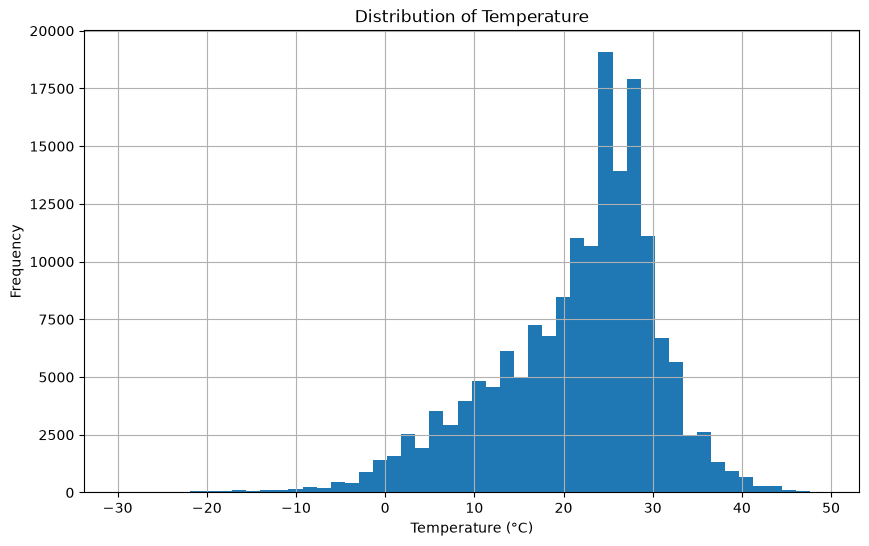

In [79]:
plt.figure(figsize=(10, 6))

weather["temperature_celsius"].hist(bins=50)

plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

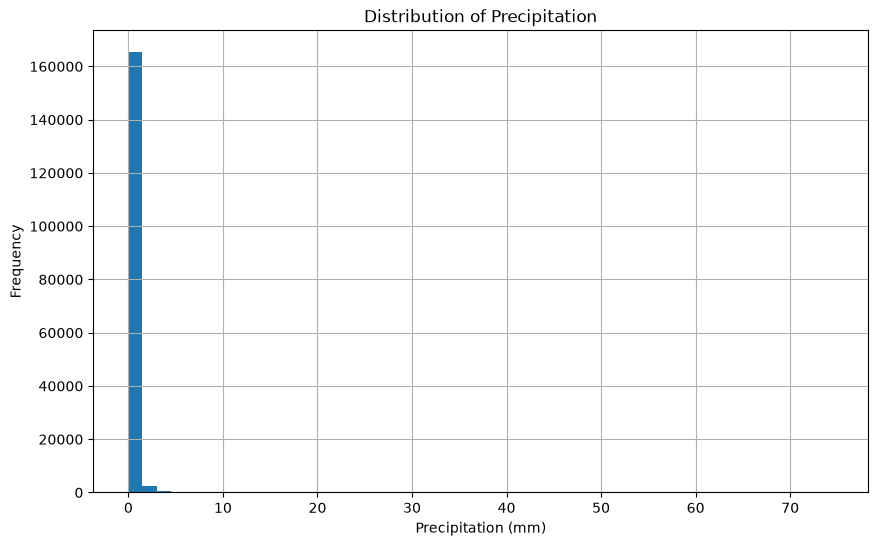

In [80]:
plt.figure(figsize=(10, 6))

weather["precip_mm"].hist(bins=50)

plt.title("Distribution of Precipitation")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.show()

In [81]:
monthly_temp = (
    weather
    .groupby("month")["temperature_celsius"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

monthly_temp

,month,mean,min,max
0,1,16.072073,-29.8,41.4
1,2,16.713934,-26.9,37.4
2,3,18.696641,-23.9,40.0
3,4,20.706085,-16.4,43.2
4,5,22.961891,-1.0,47.7
5,6,24.791750,-3.7,49.2
6,7,25.053091,-8.8,49.1
7,8,24.793068,-25.4,48.2
8,9,23.401902,-2.7,47.2
9,10,21.587429,-10.4,41.8


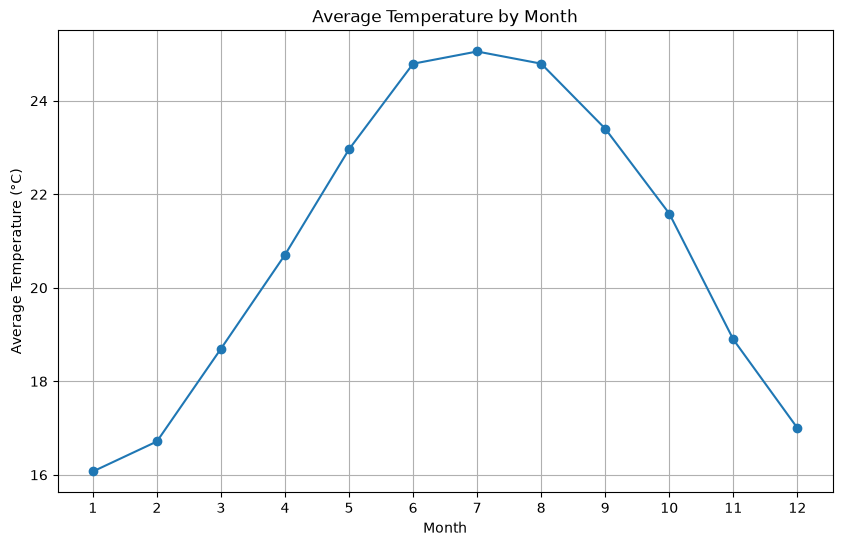

In [82]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_temp["month"],
    monthly_temp["mean"],
    marker="o"
)

plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [83]:
seasonal_temp = (
    weather
    .groupby("season")["temperature_celsius"]
    .agg(["mean", "min", "max", "std"])
    .reindex(["Winter", "Spring", "Summer", "Fall"])
)

seasonal_temp

,mean,min,max,std
season,,,,
Winter,16.595733,-29.8,41.4,11.416507
Spring,20.981658,-23.9,47.7,8.816654
Summer,24.878830,-25.4,49.2,7.199779
Fall,21.598008,-20.1,47.2,8.161378


<Figure size 1000x600 with 0 Axes>

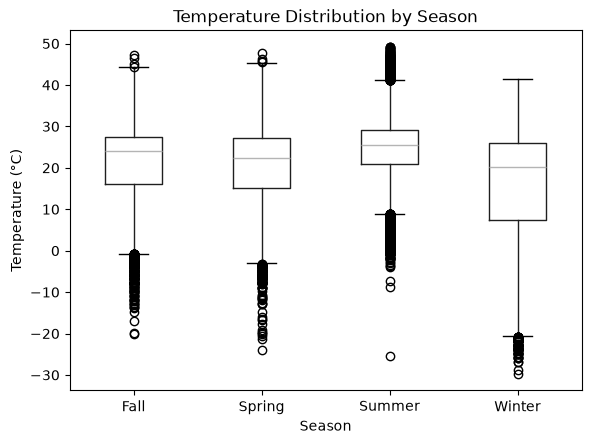

In [84]:
plt.figure(figsize=(10, 6))

weather.boxplot(
    column="temperature_celsius",
    by="season",
    grid=False
)

plt.title("Temperature Distribution by Season")
plt.suptitle("")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")
plt.show()

In [85]:
monthly_trend = (
    weather
    .set_index("last_updated")
    .resample("ME")["temperature_celsius"]
    .mean()
    .reset_index()
)

monthly_trend.head()

,last_updated,temperature_celsius
0,2024-05-31,25.153214
1,2024-06-30,26.456036
2,2024-07-31,26.800448
3,2024-08-31,26.789677
4,2024-09-30,25.124402


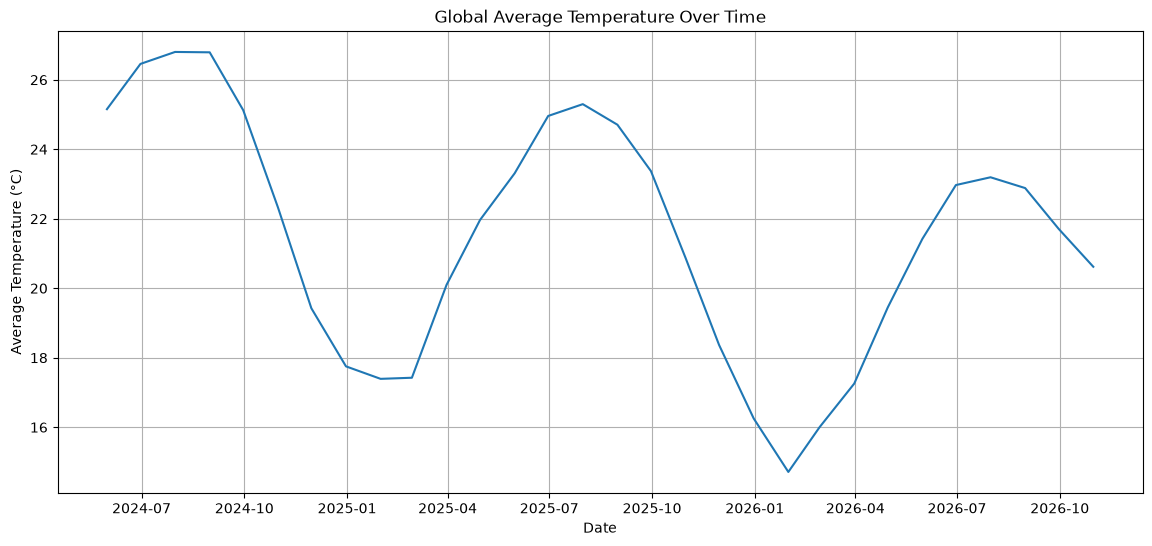

In [86]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_trend["last_updated"],
    monthly_trend["temperature_celsius"]
)

plt.title("Global Average Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

In [87]:
location_temperature = (
    weather
    .groupby(["country", "location_name"])["temperature_celsius"]
    .agg(["mean", "min", "max"])
    .sort_values("mean", ascending=False)
)

location_temperature.head(10)

,,mean,min,max
country,location_name,,,
Saudi Arabien,Ar Riyadh,45.000000,45.0,45.0
Kuwait,Kuwait,44.400000,44.4,44.4
Marrocos,Morocco City,40.300000,40.3,40.3
Turkménistan,Krasnyy Turkmenistan,37.800000,37.8,37.8
Турция,Yaren,34.000000,34.0,34.0
Qatar,Doha,32.971759,15.2,46.3
United Arab Emirates,Abu Dhabi,32.545497,18.0,46.4
Cambodia,Phnom Penh,32.106257,22.6,39.9
Thailand,Bangkok,31.947977,23.9,39.3


In [88]:
location_temperature.tail(10)

,,mean,min,max
country,location_name,,,
Iceland,Grindavik,8.894444,4.0,13.0
Norway,Oslo,8.467477,-19.6,26.2
Iceland,Abaer,7.256303,-25.4,18.1
Norway,Lom,7.051515,-2.1,16.4
Canada,Ottawa,6.609375,-25.0,29.2
Iceland,Vestmannaeyjar,6.422642,-5.7,17.2
Mongolia,Ulaanbaatar,6.017688,-29.8,34.3
Iceland,Reykjavik,3.738947,-7.7,15.3
Switzerland,S-Chanf,0.534000,-16.8,12.1


In [89]:
print(weather["last_updated"].min())
print(weather["last_updated"].max())

print("\nMonth values:")
print(sorted(weather["month"].unique()))

print("\nMonth counts:")
print(weather["month"].value_counts().sort_index())

print("\nExample:")
display(
    weather[
        ["last_updated", "year", "month", "season"]
    ].head(20)
)

2024-05-16 01:45:00
2026-10-01 18:45:00

Month values:
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]

Month counts:
month
1     11845
2     10916
3     11908
4     11700
5     15369
6     17491
7     17664
8     18132
9     17558
10    12250
11    11668
12    12090
Name: count, dtype: int64

Example:


,last_updated,year,month,season
0,2024-05-31 16:15:00,2024,5,Spring
1,2024-06-01 16:30:00,2024,6,Summer
2,2024-06-04 16:15:00,2024,6,Summer
3,2024-06-05 16:15:00,2024,6,Summer
4,2024-06-11 16:15:00,2024,6,Summer
5,2024-06-14 16:00:00,2024,6,Summer
6,2024-06-15 16:00:00,2024,6,Summer
7,2024-06-16 15:45:00,2024,6,Summer
8,2024-06-20 15:45:00,2024,6,Summer
9,2024-06-21 15:45:00,2024,6,Summer


In [90]:
monthly_precip = (
    weather
    .groupby("month")["precip_mm"]
    .agg(["mean", "median", "max", "std"])
    .reset_index()
)

monthly_precip

,month,mean,median,max,std
0,1,0.122429,0.0,13.70,0.494619
1,2,0.105888,0.0,7.12,0.379951
2,3,0.122223,0.0,21.56,0.528595
3,4,0.114408,0.0,14.62,0.464509
4,5,0.133437,0.0,31.57,0.580555
5,6,0.131804,0.0,22.65,0.584389
6,7,0.151141,0.0,27.40,0.629530
7,8,0.144229,0.0,49.65,0.712886
8,9,0.158200,0.0,74.52,0.907750
9,10,0.128305,0.0,26.38,0.552149


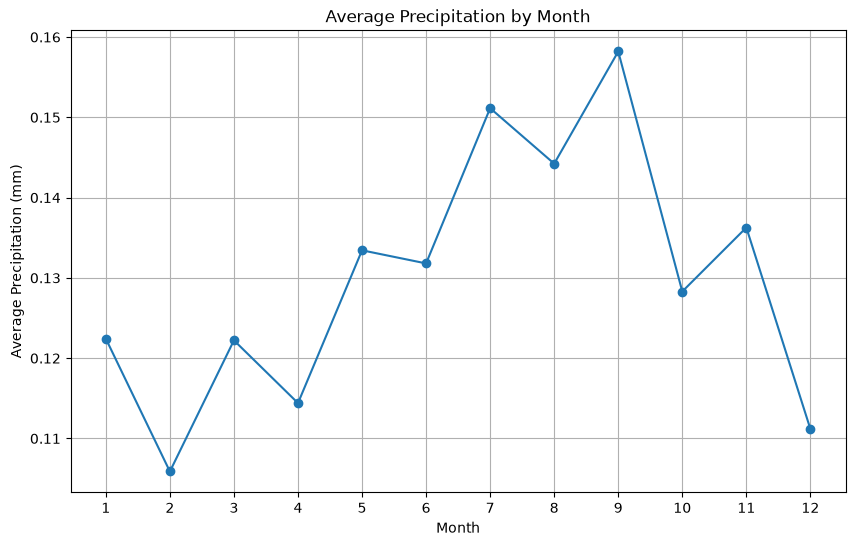

In [91]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_precip["month"],
    monthly_precip["mean"],
    marker="o"
)

plt.title("Average Precipitation by Month")
plt.xlabel("Month")
plt.ylabel("Average Precipitation (mm)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [92]:
seasonal_precip = (
    weather
    .groupby("season")["precip_mm"]
    .agg(["mean", "median", "max", "std"])
    .reindex(["Winter", "Spring", "Summer", "Fall"])
)

seasonal_precip

,mean,median,max,std
season,,,,
Winter,0.113345,0.0,17.83,0.435888
Spring,0.124299,0.0,31.57,0.532055
Summer,0.142442,0.0,49.65,0.645325
Fall,0.143203,0.0,74.52,0.743037


<Figure size 1000x600 with 0 Axes>

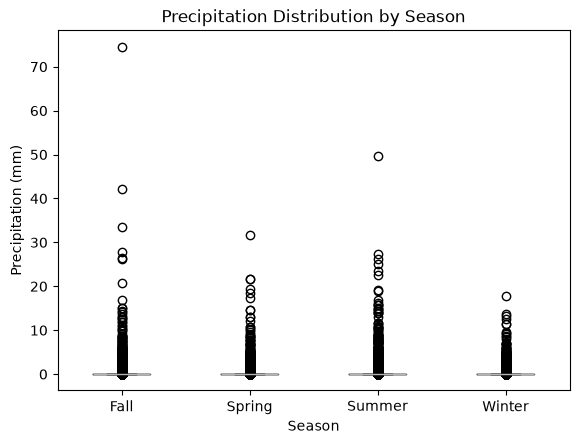

In [93]:
plt.figure(figsize=(10, 6))

weather.boxplot(
    column="precip_mm",
    by="season",
    grid=False
)

plt.title("Precipitation Distribution by Season")
plt.suptitle("")
plt.xlabel("Season")
plt.ylabel("Precipitation (mm)")
plt.show()

In [94]:
location_precip = (
    weather
    .groupby(["country", "location_name"])["precip_mm"]
    .agg(["mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

location_precip.head(10)

mean  median   max
country                          location_name                          
Letonia                          Riga             1.830000   1.830  1.83
USA United States of America     Palau            1.590000   1.590  1.59
Malásia                          Ivory Ivory Ban  1.550000   1.550  1.55
Australia                        Melbourne        1.220000   1.220  2.44
Lao People's Democratic Republic Vientiane        1.005000   1.005  1.97
Myanmar                          Abazu            0.954681   0.870  2.90
                                 Namawbin         0.818056   0.365  2.90
                                 Pathein          0.769375   0.000  5.01
Cameroon                         Bafoussam        0.663333   0.610  1.90
Malaysia                         Kuala Lumpur     0.582983   0.310  4.99

In [95]:
rain_frequency = (
    weather
    .groupby(["country", "location_name"])["precip_mm"]
    .apply(lambda x: (x > 0).mean() * 100)
    .sort_values(ascending=False)
)

rain_frequency.head(10)

country                          location_name   
كولومبيا                         Costa Rica          100.0
Vietnam                          Ho Chi Minh City    100.0
USA United States of America     Palau               100.0
Togo                             Lome                100.0
Malásia                          Ivory Ivory Ban     100.0
Maldives                         Male                100.0
Jemen                            Sanaa               100.0
United States of America         Palau               100.0
Kosovo                           Pristina            100.0
Saint-Vincent-et-les-Grenadines  Kingstown           100.0
Name: precip_mm, dtype: float64

In [96]:
correlation_columns = [
    "temperature_celsius",
    "precip_mm",
    "humidity",
    "wind_kph",
    "pressure_mb",
    "visibility_km",
    "uv_index",
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5",
    "air_quality_PM10"
]

correlation_matrix = weather[correlation_columns].corr()

correlation_matrix.round(2)

,temperature_celsius,precip_mm,humidity,wind_kph,pressure_mb,visibility_km,uv_index,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10
temperature_celsius,1.00,0.03,-0.34,0.13,-0.41,0.10,0.48,-0.01,0.26,-0.13,-0.04,0.07,0.12
precip_mm,0.03,1.00,0.16,0.02,-0.11,-0.04,-0.04,0.01,-0.05,-0.03,-0.03,-0.05,-0.04
humidity,-0.34,0.16,1.00,-0.09,0.02,-0.11,-0.53,-0.08,-0.41,-0.11,-0.18,-0.22,-0.24
wind_kph,0.13,0.02,-0.09,1.00,-0.17,0.12,0.08,-0.13,0.15,-0.16,-0.09,-0.04,0.08
pressure_mb,-0.41,-0.11,0.02,-0.17,1.00,-0.01,-0.11,0.02,-0.16,0.07,0.04,-0.00,-0.04
visibility_km,0.10,-0.04,-0.11,0.12,-0.01,1.00,0.03,-0.07,0.02,-0.08,-0.07,-0.12,-0.06
uv_index,0.48,-0.04,-0.53,0.08,-0.11,0.03,1.00,0.01,0.38,-0.05,0.03,0.08,0.12
air_quality_Carbon_Monoxide,-0.01,0.01,-0.08,-0.13,0.02,-0.07,0.01,1.00,-0.07,0.61,0.52,0.61,0.16
air_quality_Ozone,0.26,-0.05,-0.41,0.15,-0.16,0.02,0.38,-0.07,1.00,-0.22,-0.04,0.06,0.09
air_quality_Nitrogen_dioxide,-0.13,-0.03,-0.11,-0.16,0.07,-0.08,-0.05,0.61,-0.22,1.00,0.69,0.53,0.19


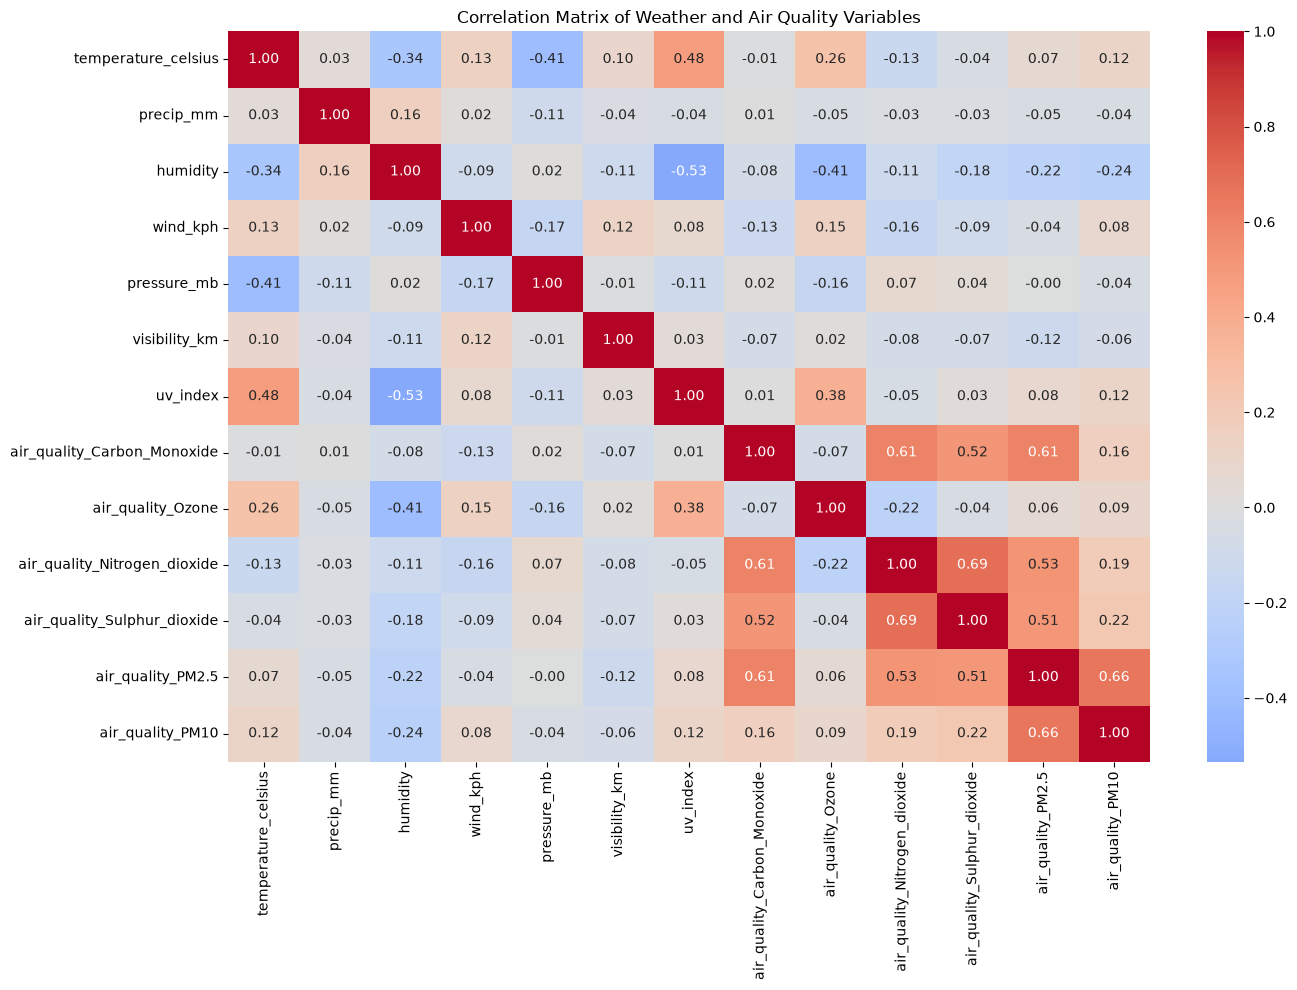

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Weather and Air Quality Variables")
plt.tight_layout()
plt.show()

In [98]:
corr_pairs = (
    correlation_matrix
    .where(
        ~np.tril(
            np.ones(correlation_matrix.shape)
        ).astype(bool)
    )
    .stack()
    .sort_values(key=abs, ascending=False)
)

corr_pairs.head(15)

air_quality_Nitrogen_dioxide  air_quality_Sulphur_dioxide     0.692203
air_quality_PM2.5             air_quality_PM10                0.660335
air_quality_Carbon_Monoxide   air_quality_PM2.5               0.607977
                              air_quality_Nitrogen_dioxide    0.605522
humidity                      uv_index                       -0.533948
air_quality_Nitrogen_dioxide  air_quality_PM2.5               0.525375
air_quality_Carbon_Monoxide   air_quality_Sulphur_dioxide     0.519243
air_quality_Sulphur_dioxide   air_quality_PM2.5               0.509040
temperature_celsius           uv_index                        0.477085
                              pressure_mb                    -0.408851
humidity                      air_quality_Ozone              -0.407323
uv_index                      air_quality_Ozone               0.377475
temperature_celsius           humidity                       -0.338995
                              air_quality_Ozone               0.261651
humidi

In [99]:
weather_air_quality = correlation_matrix.loc[
    [
        "temperature_celsius",
        "precip_mm",
        "humidity",
        "wind_kph",
        "pressure_mb",
        "visibility_km",
        "uv_index"
    ],
    [
        "air_quality_Carbon_Monoxide",
        "air_quality_Ozone",
        "air_quality_Nitrogen_dioxide",
        "air_quality_Sulphur_dioxide",
        "air_quality_PM2.5",
        "air_quality_PM10"
    ]
]

weather_air_quality.round(2)

,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10
temperature_celsius,-0.01,0.26,-0.13,-0.04,0.07,0.12
precip_mm,0.01,-0.05,-0.03,-0.03,-0.05,-0.04
humidity,-0.08,-0.41,-0.11,-0.18,-0.22,-0.24
wind_kph,-0.13,0.15,-0.16,-0.09,-0.04,0.08
pressure_mb,0.02,-0.16,0.07,0.04,-0.00,-0.04
visibility_km,-0.07,0.02,-0.08,-0.07,-0.12,-0.06
uv_index,0.01,0.38,-0.05,0.03,0.08,0.12


In [100]:
location_counts = (
    weather
    .groupby(["country", "location_name"])
    .size()
    .sort_values(ascending=False)
)

location_counts.head(20)

country               location_name
Ukraine               Kyiv             867
Yemen                 Sanaa            867
Burundi               Bujumbura        867
Chad                  N'djamena        867
Vatican City          Vatican City     867
Eritrea               Asmara           867
Equatorial Guinea     Malabo           867
Malta                 Valletta         867
Uzbekistan            Tashkent         867
Iraq                  Baghdad          867
Japan                 Tokyo            867
Ghana                 Accra            867
Poland                Warsaw           867
Senegal               Dakar            867
Uganda                Kampala          866
United Arab Emirates  Abu Dhabi        866
Afghanistan           Kabul            866
Zambia                Lusaka           866
Slovakia              Bratislava       866
Singapore             Singapore        866
dtype: int64

In [101]:
top_locations = location_counts.head(10)

top_locations

country            location_name
Ukraine            Kyiv             867
Yemen              Sanaa            867
Burundi            Bujumbura        867
Chad               N'djamena        867
Vatican City       Vatican City     867
Eritrea            Asmara           867
Equatorial Guinea  Malabo           867
Malta              Valletta         867
Uzbekistan         Tashkent         867
Iraq               Baghdad          867
dtype: int64

In [102]:
for country, location in top_locations.index:
    location_data = weather[
        (weather["country"] == country) &
        (weather["location_name"] == location)
    ]

    print(
        f"{country} | {location} | "
        f"Rows: {len(location_data)} | "
        f"Start: {location_data['last_updated'].min()} | "
        f"End: {location_data['last_updated'].max()}"
    )

Ukraine | Kyiv | Rows: 867 | Start: 2024-05-16 11:45:00 | End: 2026-10-01 08:45:00
Yemen | Sanaa | Rows: 867 | Start: 2024-05-16 11:45:00 | End: 2026-10-01 08:45:00
Burundi | Bujumbura | Rows: 867 | Start: 2024-05-16 10:45:00 | End: 2026-10-01 07:30:00
Chad | N'djamena | Rows: 867 | Start: 2024-05-16 09:45:00 | End: 2026-10-01 06:45:00
Vatican City | Vatican City | Rows: 867 | Start: 2024-05-16 10:45:00 | End: 2026-10-01 07:30:00
Eritrea | Asmara | Rows: 867 | Start: 2024-05-16 11:45:00 | End: 2026-10-01 08:45:00
Equatorial Guinea | Malabo | Rows: 867 | Start: 2024-05-16 09:45:00 | End: 2026-10-01 06:45:00
Malta | Valletta | Rows: 867 | Start: 2024-05-16 10:45:00 | End: 2026-10-01 07:45:00
Uzbekistan | Tashkent | Rows: 867 | Start: 2024-05-16 13:45:00 | End: 2026-10-01 10:45:00
Iraq | Baghdad | Rows: 867 | Start: 2024-05-16 11:45:00 | End: 2026-10-01 08:45:00


In [103]:
kyiv = weather[
    (weather["country"] == "Ukraine") &
    (weather["location_name"] == "Kyiv")
].copy()

kyiv = kyiv.sort_values("last_updated")

print("Rows:", len(kyiv))
print("Start:", kyiv["last_updated"].min())
print("End:", kyiv["last_updated"].max())

display(
    kyiv[
        [
            "last_updated",
            "temperature_celsius",
            "precip_mm",
            "humidity",
            "wind_kph"
        ]
    ].head(10)
)

Rows: 867
Start: 2024-05-16 11:45:00
End: 2026-10-01 08:45:00


,last_updated,temperature_celsius,precip_mm,humidity,wind_kph
75119,2024-05-16 11:45:00,13.8,0.25,53,13.0
75120,2024-05-16 17:00:00,14.6,0.06,51,9.0
75121,2024-05-17 19:00:00,16.4,0.00,59,11.5
75122,2024-05-18 17:30:00,19.8,0.21,49,6.5
75123,2024-05-19 17:15:00,21.3,0.00,44,10.8
75124,2024-05-20 17:45:00,21.7,0.00,44,15.1
75125,2024-05-21 17:45:00,22.8,0.00,43,14.0
75126,2024-05-22 17:15:00,19.9,0.11,62,7.6
75127,2024-05-23 17:00:00,18.4,1.05,68,18.4
75128,2024-05-24 17:30:00,21.5,0.01,60,19.4


In [104]:
kyiv["date"] = kyiv["last_updated"].dt.date

daily_counts = (
    kyiv.groupby("date")
    .size()
)

print("Unique dates:", daily_counts.shape[0])

print("\nObservations per day:")
print(daily_counts.value_counts().sort_index())

print("\nDays with multiple observations:")
display(
    daily_counts[daily_counts > 1].head(20)
)

Unique dates: 866

Observations per day:
1    865
2      1
Name: count, dtype: int64

Days with multiple observations:


date
2024-05-16    2
dtype: int64

In [105]:
full_dates = pd.date_range(
    start=kyiv["last_updated"].dt.normalize().min(),
    end=kyiv["last_updated"].dt.normalize().max(),
    freq="D"
)

observed_dates = pd.to_datetime(
    kyiv["date"].astype(str)
).unique()

missing_dates = full_dates[
    ~full_dates.isin(observed_dates)
]

print("Expected dates:", len(full_dates))
print("Observed dates:", len(observed_dates))
print("Missing dates:", len(missing_dates))

print("\nFirst missing dates:")
print(missing_dates[:20])

Expected dates: 869
Observed dates: 866
Missing dates: 3

First missing dates:
DatetimeIndex(['2024-07-21', '2024-07-22', '2026-01-19'], dtype='datetime64[us]', freq=None)


In [106]:
kyiv_daily = (
    kyiv
    .set_index("last_updated")
    .resample("D")
    .agg({
        "temperature_celsius": "mean",
        "precip_mm": "sum",
        "humidity": "mean",
        "wind_kph": "mean",
        "pressure_mb": "mean",
        "visibility_km": "mean",
        "uv_index": "mean",
        "air_quality_Carbon_Monoxide": "mean",
        "air_quality_Ozone": "mean",
        "air_quality_Nitrogen_dioxide": "mean",
        "air_quality_Sulphur_dioxide": "mean",
        "air_quality_PM2.5": "mean",
        "air_quality_PM10": "mean"
    })
)

print("Shape:", kyiv_daily.shape)
print("\nFirst 10 days:")
display(kyiv_daily.head(10))

print("\nLast 10 days:")
display(kyiv_daily.tail(10))

Shape: (869, 13)

First 10 days:


,temperature_celsius,precip_mm,humidity,wind_kph,pressure_mb,visibility_km,uv_index,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10
last_updated,,,,,,,,,,,,,
2024-05-16,14.2,0.31,52.0,11.0,1026.5,9.5,3.0,211.95,93.7,1.05,1.75,1.85,2.2
2024-05-17,16.4,0.00,59.0,11.5,1020.0,10.0,5.0,223.60,65.8,15.90,4.20,4.70,5.8
2024-05-18,19.8,0.21,49.0,6.5,1017.0,9.0,4.0,193.60,94.4,1.00,1.20,3.40,3.6
2024-05-19,21.3,0.00,44.0,10.8,1016.0,10.0,6.0,200.30,113.0,1.90,5.80,4.70,5.1
2024-05-20,21.7,0.00,44.0,15.1,1017.0,10.0,6.0,203.60,95.8,3.70,3.80,2.10,2.6
2024-05-21,22.8,0.00,43.0,14.0,1018.0,10.0,6.0,193.60,97.3,2.40,3.20,4.50,5.0
2024-05-22,19.9,0.11,62.0,7.6,1017.0,10.0,4.0,195.30,114.4,3.50,9.80,6.40,6.9
2024-05-23,18.4,1.05,68.0,18.4,1019.0,9.0,4.0,188.60,110.2,1.20,2.20,5.10,5.3
2024-05-24,21.5,0.01,60.0,19.4,1025.0,10.0,5.0,188.60,97.3,1.20,1.40,2.00,2.1



Last 10 days:


,temperature_celsius,precip_mm,humidity,wind_kph,pressure_mb,visibility_km,uv_index,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10
last_updated,,,,,,,,,,,,,
2026-09-22,10.4,0.00,82.0,14.8,1012.0,10.0,0.7,206.0,39.0,9.4,1.3,5.7,8.7
2026-09-23,9.5,0.00,81.0,5.4,1017.0,10.0,0.2,259.0,18.0,23.8,2.9,8.6,11.0
2026-09-24,8.6,1.98,93.0,19.8,1009.0,10.0,0.0,196.0,39.0,8.6,0.9,3.3,4.2
2026-09-25,10.2,0.00,74.0,7.2,1021.0,10.0,0.2,229.0,27.0,18.7,2.3,8.1,13.5
2026-09-26,12.4,0.00,64.0,7.6,1026.0,10.0,0.2,245.0,23.0,13.2,4.1,11.6,14.8
2026-09-27,13.2,0.00,60.0,5.8,1029.0,10.0,0.2,281.0,18.0,20.6,3.7,9.8,16.8
2026-09-28,10.4,0.00,77.0,13.7,1028.0,10.0,0.2,210.0,35.0,17.5,1.8,8.1,10.6
2026-09-29,11.7,0.00,76.0,13.7,1032.0,10.0,0.6,192.0,43.0,7.4,1.7,6.1,8.2
2026-09-30,9.4,0.00,66.0,9.0,1035.0,10.0,0.2,229.0,24.0,22.4,2.4,9.2,11.9


In [107]:
print("Missing temperature dates:")

missing_temperature = kyiv_daily[
    kyiv_daily["temperature_celsius"].isna()
]

display(missing_temperature)

Missing temperature dates:


,temperature_celsius,precip_mm,humidity,wind_kph,pressure_mb,visibility_km,uv_index,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10
last_updated,,,,,,,,,,,,,
2024-07-21,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-07-22,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-19,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


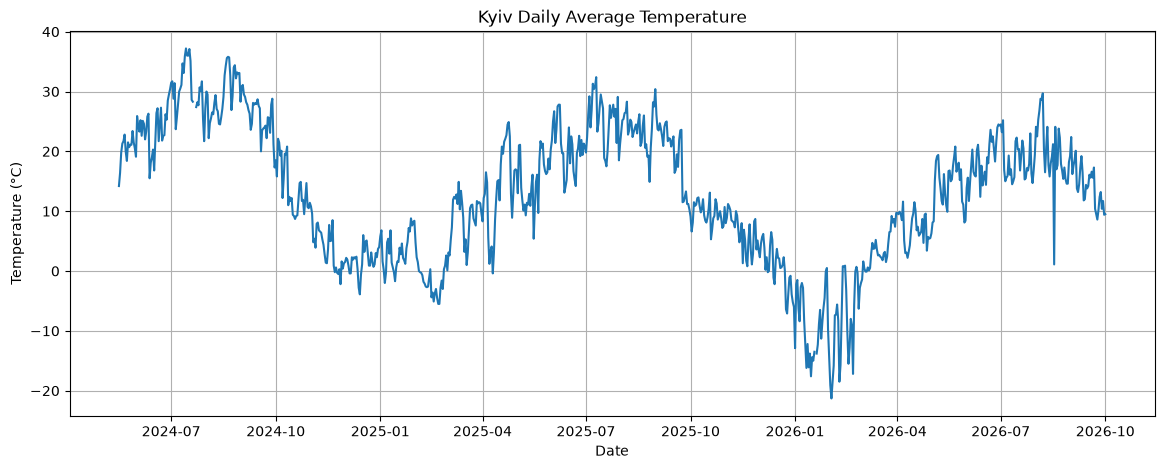

In [108]:
plt.figure(figsize=(14, 5))

plt.plot(
    kyiv_daily.index,
    kyiv_daily["temperature_celsius"]
)

plt.title("Kyiv Daily Average Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.show()

In [109]:
forecast_df = kyiv_daily[
    ["temperature_celsius"]
].copy()

forecast_df = forecast_df.rename(
    columns={
        "temperature_celsius": "temperature"
    }
)

print("Forecasting dataset shape:", forecast_df.shape)

display(forecast_df.head())

Forecasting dataset shape: (869, 1)


,temperature
last_updated,
2024-05-16,14.2
2024-05-17,16.4
2024-05-18,19.8
2024-05-19,21.3
2024-05-20,21.7


In [110]:
print("Missing target values:", forecast_df["temperature"].isna().sum())

Missing target values: 3


In [111]:
# Identify dates where there was no observation at all
missing_days = kyiv_daily["temperature_celsius"].isna()

# Convert aggregate values on those dates to NaN
kyiv_daily.loc[missing_days, :] = np.nan

print("Dates with no observations:")
display(kyiv_daily[missing_days])

Dates with no observations:


,temperature_celsius,precip_mm,humidity,wind_kph,pressure_mb,visibility_km,uv_index,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10
last_updated,,,,,,,,,,,,,
2024-07-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-07-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [112]:
print("Total completely missing days:", kyiv_daily["temperature_celsius"].isna().sum())

Total completely missing days: 3


In [113]:
forecast_df = kyiv_daily[["temperature_celsius"]].copy()

forecast_df = forecast_df.rename(
    columns={"temperature_celsius": "temperature"}
)

# Calendar features
forecast_df["month"] = forecast_df.index.month
forecast_df["day_of_year"] = forecast_df.index.dayofyear
forecast_df["day_of_week"] = forecast_df.index.dayofweek

# Historical temperature features
forecast_df["lag_1"] = forecast_df["temperature"].shift(1)
forecast_df["lag_2"] = forecast_df["temperature"].shift(2)
forecast_df["lag_7"] = forecast_df["temperature"].shift(7)
forecast_df["lag_14"] = forecast_df["temperature"].shift(14)
forecast_df["lag_30"] = forecast_df["temperature"].shift(30)

# Rolling averages
forecast_df["rolling_7"] = (
    forecast_df["temperature"]
    .rolling(window=7)
    .mean()
)

forecast_df["rolling_14"] = (
    forecast_df["temperature"]
    .rolling(window=14)
    .mean()
)

forecast_df["rolling_30"] = (
    forecast_df["temperature"]
    .rolling(window=30)
    .mean()
)

print("Shape:", forecast_df.shape)

display(forecast_df.head(15))

Shape: (869, 12)


,temperature,month,day_of_year,day_of_week,lag_1,lag_2,lag_7,lag_14,lag_30,rolling_7,rolling_14,rolling_30
last_updated,,,,,,,,,,,,
2024-05-16,14.2,5,137,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-17,16.4,5,138,4,14.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-18,19.8,5,139,5,16.4,14.2,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-19,21.3,5,140,6,19.8,16.4,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-20,21.7,5,141,0,21.3,19.8,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-21,22.8,5,142,1,21.7,21.3,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-22,19.9,5,143,2,22.8,21.7,NaN,NaN,NaN,19.442857,NaN,NaN
2024-05-23,18.4,5,144,3,19.9,22.8,14.2,NaN,NaN,20.042857,NaN,NaN
2024-05-24,21.5,5,145,4,18.4,19.9,16.4,NaN,NaN,20.771429,NaN,NaN


In [114]:
forecast_df["sin_day_of_year"] = np.sin(
    2 * np.pi * forecast_df["day_of_year"] / 365.25
)

forecast_df["cos_day_of_year"] = np.cos(
    2 * np.pi * forecast_df["day_of_year"] / 365.25
)

In [115]:
print("Columns:")
print(forecast_df.columns.tolist())

print("\nMissing values:")
print(forecast_df.isna().sum())

Columns:
['temperature', 'month', 'day_of_year', 'day_of_week', 'lag_1', 'lag_2', 'lag_7', 'lag_14', 'lag_30', 'rolling_7', 'rolling_14', 'rolling_30', 'sin_day_of_year', 'cos_day_of_year']

Missing values:
temperature         3
month               0
day_of_year         0
day_of_week         0
lag_1               4
lag_2               5
lag_7              10
lag_14             17
lag_30             33
rolling_7          21
rolling_14         42
rolling_30         90
sin_day_of_year     0
cos_day_of_year     0
dtype: int64


In [116]:
feature_columns = [
    "month",
    "day_of_year",
    "day_of_week",
    "lag_1",
    "lag_2",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_7",
    "rolling_14",
    "rolling_30",
    "sin_day_of_year",
    "cos_day_of_year"
]

model_df = forecast_df.dropna(
    subset=["temperature"] + feature_columns
).copy()

print("Original rows:", len(forecast_df))
print("Rows available for modeling:", len(model_df))
print("Rows removed:", len(forecast_df) - len(model_df))

print("\nRemaining missing values:")
print(model_df.isna().sum().sum())

Original rows: 869
Rows available for modeling: 776
Rows removed: 93

Remaining missing values:
0


In [117]:
print("Modeling period:")
print("Start:", model_df.index.min())
print("End:", model_df.index.max())

print("\nRows:", len(model_df))

print("\nMissing dates inside modeling period:")

expected_model_dates = pd.date_range(
    model_df.index.min(),
    model_df.index.max(),
    freq="D"
)

missing_model_dates = expected_model_dates[
    ~expected_model_dates.isin(model_df.index)
]

print(missing_model_dates)

Modeling period:
Start: 2024-06-15 00:00:00
End: 2026-10-01 00:00:00

Rows: 776

Missing dates inside modeling period:
DatetimeIndex(['2024-07-21', '2024-07-22', '2024-07-23', '2024-07-24',
               '2024-07-25', '2024-07-26', '2024-07-27', '2024-07-28',
               '2024-07-29', '2024-07-30', '2024-07-31', '2024-08-01',
               '2024-08-02', '2024-08-03', '2024-08-04', '2024-08-05',
               '2024-08-06', '2024-08-07', '2024-08-08', '2024-08-09',
               '2024-08-10', '2024-08-11', '2024-08-12', '2024-08-13',
               '2024-08-14', '2024-08-15', '2024-08-16', '2024-08-17',
               '2024-08-18', '2024-08-19', '2024-08-20', '2024-08-21',
               '2026-01-19', '2026-01-20', '2026-01-21', '2026-01-22',
               '2026-01-23', '2026-01-24', '2026-01-25', '2026-01-26',
               '2026-01-27', '2026-01-28', '2026-01-29', '2026-01-30',
               '2026-01-31', '2026-02-01', '2026-02-02', '2026-02-03',
               '2026-02-04', 

In [118]:
n = len(model_df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train = model_df.iloc[:train_end].copy()
validation = model_df.iloc[train_end:validation_end].copy()
test = model_df.iloc[validation_end:].copy()

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

print("\nTrain period:")
print(train.index.min(), "to", train.index.max())

print("\nValidation period:")
print(validation.index.min(), "to", validation.index.max())

print("\nTest period:")
print(test.index.min(), "to", test.index.max())

Train: (543, 14)
Validation: (116, 14)
Test: (117, 14)

Train period:
2024-06-15 00:00:00 to 2026-01-10 00:00:00

Validation period:
2026-01-11 00:00:00 to 2026-06-06 00:00:00

Test period:
2026-06-07 00:00:00 to 2026-10-01 00:00:00


In [119]:
X_train = train[feature_columns]
y_train = train["temperature"]

X_validation = validation[feature_columns]
y_validation = validation["temperature"]

X_test = test[feature_columns]
y_test = test["temperature"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (543, 13)
y_train: (543,)
X_validation: (116, 13)
y_validation: (116,)
X_test: (117, 13)
y_test: (117,)


In [120]:
kyiv[
    (kyiv["last_updated"] >= "2024-07-15") &
    (kyiv["last_updated"] <= "2024-08-25")
][
    ["last_updated", "temperature_celsius"]
].head(20)

,last_updated,temperature_celsius
75180,2024-07-15 16:00:00,36.0
75181,2024-07-16 15:45:00,36.0
75182,2024-07-17 15:45:00,37.1
75183,2024-07-18 15:45:00,35.1
75184,2024-07-19 15:30:00,28.6
75185,2024-07-20 15:45:00,28.3
75186,2024-07-23 15:30:00,27.4
75187,2024-07-24 15:45:00,28.2
75188,2024-07-25 15:30:00,27.7
75189,2024-07-26 15:30:00,30.7


In [121]:
kyiv[
    (kyiv["last_updated"] >= "2026-01-10") &
    (kyiv["last_updated"] <= "2026-02-25")
][
    ["last_updated", "temperature_celsius"]
].head(20)

,last_updated,temperature_celsius
75722,2026-01-10 09:30:00,-12.1
75723,2026-01-11 09:00:00,-16.2
75724,2026-01-12 09:15:00,-12.2
75725,2026-01-13 09:30:00,-16.1
75726,2026-01-14 09:30:00,-13.8
75727,2026-01-15 09:15:00,-17.6
75728,2026-01-16 09:15:00,-14.4
75729,2026-01-17 09:00:00,-15.0
75730,2026-01-18 09:00:00,-13.5
75731,2026-01-20 09:15:00,-13.8


In [123]:
print("Around July/August 2024:")
display(
    kyiv[
        (kyiv["last_updated"] >= "2024-07-15") &
        (kyiv["last_updated"] <= "2024-08-25")
    ][["last_updated", "temperature_celsius"]]
)

print("\nAround January/February 2026:")
display(
    kyiv[
        (kyiv["last_updated"] >= "2026-01-10") &
        (kyiv["last_updated"] <= "2026-02-25")
    ][["last_updated", "temperature_celsius"]]
)

Around July/August 2024:


,last_updated,temperature_celsius
75180,2024-07-15 16:00:00,36.0
75181,2024-07-16 15:45:00,36.0
75182,2024-07-17 15:45:00,37.1
75183,2024-07-18 15:45:00,35.1
75184,2024-07-19 15:30:00,28.6
75185,2024-07-20 15:45:00,28.3
75186,2024-07-23 15:30:00,27.4
75187,2024-07-24 15:45:00,28.2
75188,2024-07-25 15:30:00,27.7
75189,2024-07-26 15:30:00,30.7



Around January/February 2026:


,last_updated,temperature_celsius
75722,2026-01-10 09:30:00,-12.1
75723,2026-01-11 09:00:00,-16.2
75724,2026-01-12 09:15:00,-12.2
75725,2026-01-13 09:30:00,-16.1
75726,2026-01-14 09:30:00,-13.8
75727,2026-01-15 09:15:00,-17.6
75728,2026-01-16 09:15:00,-14.4
75729,2026-01-17 09:00:00,-15.0
75730,2026-01-18 09:00:00,-13.5
75731,2026-01-20 09:15:00,-13.8


In [124]:
# Start from the daily Kyiv dataset
forecast_df = kyiv_daily[["temperature_celsius"]].copy()

forecast_df = forecast_df.rename(
    columns={"temperature_celsius": "temperature"}
)

# Calendar features
forecast_df["month"] = forecast_df.index.month
forecast_df["day_of_year"] = forecast_df.index.dayofyear
forecast_df["day_of_week"] = forecast_df.index.dayofweek

# Temperature lags
forecast_df["lag_1"] = forecast_df["temperature"].shift(1)
forecast_df["lag_2"] = forecast_df["temperature"].shift(2)
forecast_df["lag_7"] = forecast_df["temperature"].shift(7)
forecast_df["lag_14"] = forecast_df["temperature"].shift(14)

# Rolling features
forecast_df["rolling_7"] = (
    forecast_df["temperature"]
    .rolling(window=7, min_periods=3)
    .mean()
)

forecast_df["rolling_14"] = (
    forecast_df["temperature"]
    .rolling(window=14, min_periods=7)
    .mean()
)

# Seasonal cyclical features
forecast_df["sin_day_of_year"] = np.sin(
    2 * np.pi * forecast_df["day_of_year"] / 365.25
)

forecast_df["cos_day_of_year"] = np.cos(
    2 * np.pi * forecast_df["day_of_year"] / 365.25
)

print("Shape:", forecast_df.shape)

print("\nMissing values:")
print(forecast_df.isna().sum())

Shape: (869, 12)

Missing values:
temperature         3
month               0
day_of_year         0
day_of_week         0
lag_1               4
lag_2               5
lag_7              10
lag_14             17
rolling_7           2
rolling_14          6
sin_day_of_year     0
cos_day_of_year     0
dtype: int64


In [125]:
feature_columns = [
    "month",
    "day_of_year",
    "day_of_week",
    "lag_1",
    "lag_2",
    "lag_7",
    "lag_14",
    "rolling_7",
    "rolling_14",
    "sin_day_of_year",
    "cos_day_of_year"
]

model_df = forecast_df.dropna(
    subset=["temperature"] + feature_columns
).copy()

print("Original rows:", len(forecast_df))
print("Rows available for modeling:", len(model_df))
print("Rows removed:", len(forecast_df) - len(model_df))

print("\nRemaining missing values:")
print(model_df.isna().sum().sum())

Original rows: 869
Rows available for modeling: 842
Rows removed: 27

Remaining missing values:
0


In [126]:
expected_dates = pd.date_range(
    model_df.index.min(),
    model_df.index.max(),
    freq="D"
)

missing_dates = expected_dates[
    ~expected_dates.isin(model_df.index)
]

print("Modeling period:")
print(model_df.index.min(), "to", model_df.index.max())

print("\nModeling rows:", len(model_df))

print("\nNumber of missing calendar dates:", len(missing_dates))

print("\nFirst 20 missing dates:")
print(missing_dates[:20])

Modeling period:
2024-05-30 00:00:00 to 2026-10-01 00:00:00

Modeling rows: 842

Number of missing calendar dates: 13

First 20 missing dates:
DatetimeIndex(['2024-07-21', '2024-07-22', '2024-07-23', '2024-07-24',
               '2024-07-28', '2024-07-29', '2024-08-04', '2024-08-05',
               '2026-01-19', '2026-01-20', '2026-01-21', '2026-01-26',
               '2026-02-02'],
              dtype='datetime64[us]', freq=None)


In [127]:
# Start fresh from the daily temperature series
forecast_df = kyiv_daily[["temperature_celsius"]].copy()

forecast_df = forecast_df.rename(
    columns={"temperature_celsius": "temperature"}
)

# Calendar features
forecast_df["month"] = forecast_df.index.month
forecast_df["day_of_year"] = forecast_df.index.dayofyear
forecast_df["day_of_week"] = forecast_df.index.dayofweek

# Create true calendar-based lag features
forecast_df["lag_1"] = forecast_df["temperature"].reindex(
    forecast_df.index - pd.Timedelta(days=1)
).values

forecast_df["lag_2"] = forecast_df["temperature"].reindex(
    forecast_df.index - pd.Timedelta(days=2)
).values

forecast_df["lag_7"] = forecast_df["temperature"].reindex(
    forecast_df.index - pd.Timedelta(days=7)
).values

forecast_df["lag_14"] = forecast_df["temperature"].reindex(
    forecast_df.index - pd.Timedelta(days=14)
).values

# Rolling averages based on calendar time
forecast_df["rolling_7"] = (
    forecast_df["temperature"]
    .rolling("7D", min_periods=3)
    .mean()
)

forecast_df["rolling_14"] = (
    forecast_df["temperature"]
    .rolling("14D", min_periods=7)
    .mean()
)

# Cyclical annual features
forecast_df["sin_day_of_year"] = np.sin(
    2 * np.pi * forecast_df["day_of_year"] / 365.25
)

forecast_df["cos_day_of_year"] = np.cos(
    2 * np.pi * forecast_df["day_of_year"] / 365.25
)

print("Shape:", forecast_df.shape)

print("\nMissing values:")
print(forecast_df.isna().sum())

Shape: (869, 12)

Missing values:
temperature         3
month               0
day_of_year         0
day_of_week         0
lag_1               4
lag_2               5
lag_7              10
lag_14             17
rolling_7           2
rolling_14          6
sin_day_of_year     0
cos_day_of_year     0
dtype: int64


In [128]:
display(
    forecast_df.loc[
        "2024-07-18":"2024-07-30",
        [
            "temperature",
            "lag_1",
            "lag_2",
            "lag_7",
            "lag_14",
            "rolling_7"
        ]
    ]
)

,temperature,lag_1,lag_2,lag_7,lag_14,rolling_7
last_updated,,,,,,
2024-07-18,35.1,37.1,36.0,34.7,31.4,35.771429
2024-07-19,28.6,35.1,37.1,33.1,23.7,35.128571
2024-07-20,28.3,28.6,35.1,35.9,25.7,34.042857
2024-07-21,NaN,28.3,28.6,37.2,27.9,33.516667
2024-07-22,NaN,NaN,28.3,36.0,30.0,33.020000
2024-07-23,27.4,NaN,NaN,36.0,30.5,31.300000
2024-07-24,28.2,27.4,NaN,37.1,31.1,29.520000
2024-07-25,27.7,28.2,27.4,35.1,34.7,28.040000
2024-07-26,30.7,27.7,28.2,28.6,33.1,28.460000


In [129]:
feature_columns = [
    "month",
    "day_of_year",
    "day_of_week",
    "lag_1",
    "lag_2",
    "lag_7",
    "lag_14",
    "rolling_7",
    "rolling_14",
    "sin_day_of_year",
    "cos_day_of_year"
]

model_df = forecast_df.dropna(
    subset=["temperature"] + feature_columns
).copy()

print("Original rows:", len(forecast_df))
print("Rows available for modeling:", len(model_df))
print("Rows removed:", len(forecast_df) - len(model_df))

print("\nRemaining missing values:")
print(model_df.isna().sum().sum())

Original rows: 869
Rows available for modeling: 842
Rows removed: 27

Remaining missing values:
0


In [130]:
expected_dates = pd.date_range(
    model_df.index.min(),
    model_df.index.max(),
    freq="D"
)

missing_dates = expected_dates[
    ~expected_dates.isin(model_df.index)
]

print("Modeling period:")
print(model_df.index.min(), "to", model_df.index.max())

print("\nModeling rows:", len(model_df))

print("\nMissing calendar dates:", len(missing_dates))

print("\nMissing dates:")
print(missing_dates)

Modeling period:
2024-05-30 00:00:00 to 2026-10-01 00:00:00

Modeling rows: 842

Missing calendar dates: 13

Missing dates:
DatetimeIndex(['2024-07-21', '2024-07-22', '2024-07-23', '2024-07-24',
               '2024-07-28', '2024-07-29', '2024-08-04', '2024-08-05',
               '2026-01-19', '2026-01-20', '2026-01-21', '2026-01-26',
               '2026-02-02'],
              dtype='datetime64[us]', freq=None)


In [131]:
# Chronological train / validation / test split
n = len(model_df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train = model_df.iloc[:train_end].copy()
validation = model_df.iloc[train_end:validation_end].copy()
test = model_df.iloc[validation_end:].copy()

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

print("\nTrain period:")
print(train.index.min(), "to", train.index.max())

print("\nValidation period:")
print(validation.index.min(), "to", validation.index.max())

print("\nTest period:")
print(test.index.min(), "to", test.index.max())

Train: (589, 12)
Validation: (126, 12)
Test: (127, 12)

Train period:
2024-05-30 00:00:00 to 2026-01-16 00:00:00

Validation period:
2026-01-17 00:00:00 to 2026-05-27 00:00:00

Test period:
2026-05-28 00:00:00 to 2026-10-01 00:00:00


In [132]:
feature_columns = [
    "month",
    "day_of_year",
    "day_of_week",
    "lag_1",
    "lag_2",
    "lag_7",
    "lag_14",
    "rolling_7",
    "rolling_14",
    "sin_day_of_year",
    "cos_day_of_year"
]

X_train = train[feature_columns]
y_train = train["temperature"]

X_validation = validation[feature_columns]
y_validation = validation["temperature"]

X_test = test[feature_columns]
y_test = test["temperature"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (589, 11)
y_train: (589,)
X_validation: (126, 11)
y_validation: (126,)
X_test: (127, 11)
y_test: (127,)


In [133]:
# Naive baseline
baseline_predictions = test["lag_1"]

print("Baseline predictions:", len(baseline_predictions))
print("Actual values:", len(y_test))

Baseline predictions: 127
Actual values: 127


In [134]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Naive Baseline Results")
print("----------------------")
print(f"MAE:  {baseline_mae:.3f} °C")
print(f"RMSE: {baseline_rmse:.3f} °C")
print(f"R²:   {baseline_r2:.3f}")

Naive Baseline Results
----------------------
MAE:  2.695 °C
RMSE: 4.078 °C
R²:   0.234


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_validation_pred = ridge_model.predict(X_validation)

ridge_validation_mae = mean_absolute_error(
    y_validation,
    ridge_validation_pred
)

ridge_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        ridge_validation_pred
    )
)

ridge_validation_r2 = r2_score(
    y_validation,
    ridge_validation_pred
)

print("Ridge Regression - Validation Results")
print("--------------------------------------")
print(f"MAE:  {ridge_validation_mae:.3f} °C")
print(f"RMSE: {ridge_validation_rmse:.3f} °C")
print(f"R²:   {ridge_validation_r2:.3f}")

Ridge Regression - Validation Results
--------------------------------------
MAE:  2.291 °C
RMSE: 3.099 °C
R²:   0.893


In [136]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_validation_pred = rf_model.predict(X_validation)

rf_validation_mae = mean_absolute_error(
    y_validation,
    rf_validation_pred
)

rf_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        rf_validation_pred
    )
)

rf_validation_r2 = r2_score(
    y_validation,
    rf_validation_pred
)

print("Random Forest - Validation Results")
print("----------------------------------")
print(f"MAE:  {rf_validation_mae:.3f} °C")
print(f"RMSE: {rf_validation_rmse:.3f} °C")
print(f"R²:   {rf_validation_r2:.3f}")

Random Forest - Validation Results
----------------------------------
MAE:  2.989 °C
RMSE: 4.281 °C
R²:   0.795


In [137]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

hgb_model.fit(X_train, y_train)

hgb_validation_pred = hgb_model.predict(X_validation)

hgb_validation_mae = mean_absolute_error(
    y_validation,
    hgb_validation_pred
)

hgb_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        hgb_validation_pred
    )
)

hgb_validation_r2 = r2_score(
    y_validation,
    hgb_validation_pred
)

print("HistGradientBoosting - Validation Results")
print("------------------------------------------")
print(f"MAE:  {hgb_validation_mae:.3f} °C")
print(f"RMSE: {hgb_validation_rmse:.3f} °C")
print(f"R²:   {hgb_validation_r2:.3f}")

HistGradientBoosting - Validation Results
------------------------------------------
MAE:  2.794 °C
RMSE: 3.781 °C
R²:   0.840


In [138]:
model_comparison = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "MAE": [
        ridge_validation_mae,
        rf_validation_mae,
        hgb_validation_mae
    ],
    "RMSE": [
        ridge_validation_rmse,
        rf_validation_rmse,
        hgb_validation_rmse
    ],
    "R2": [
        ridge_validation_r2,
        rf_validation_r2,
        hgb_validation_r2
    ]
})

model_comparison = model_comparison.sort_values(
    "MAE"
).reset_index(drop=True)

model_comparison

,Model,MAE,RMSE,R2
0,Ridge Regression,2.291019,3.098781,0.892501
1,HistGradientBoosting,2.793906,3.781435,0.839920
2,Random Forest,2.989177,4.280685,0.794860


In [139]:
# Calculate inverse-MAE weights using validation performance
maes = np.array([
    ridge_validation_mae,
    rf_validation_mae,
    hgb_validation_mae
])

inverse_mae_weights = 1 / maes
ensemble_weights = inverse_mae_weights / inverse_mae_weights.sum()

print("Ensemble weights:")
print(f"Ridge:                 {ensemble_weights[0]:.3f}")
print(f"Random Forest:         {ensemble_weights[1]:.3f}")
print(f"HistGradientBoosting:  {ensemble_weights[2]:.3f}")
print(f"Total:                 {ensemble_weights.sum():.3f}")

Ensemble weights:
Ridge:                 0.387
Random Forest:         0.296
HistGradientBoosting:  0.317
Total:                 1.000


In [140]:
ensemble_validation_pred = (
    ensemble_weights[0] * ridge_validation_pred +
    ensemble_weights[1] * rf_validation_pred +
    ensemble_weights[2] * hgb_validation_pred
)

ensemble_validation_mae = mean_absolute_error(
    y_validation,
    ensemble_validation_pred
)

ensemble_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        ensemble_validation_pred
    )
)

ensemble_validation_r2 = r2_score(
    y_validation,
    ensemble_validation_pred
)

print("Ensemble - Validation Results")
print("-----------------------------")
print(f"MAE:  {ensemble_validation_mae:.3f} °C")
print(f"RMSE: {ensemble_validation_rmse:.3f} °C")
print(f"R²:   {ensemble_validation_r2:.3f}")

Ensemble - Validation Results
-----------------------------
MAE:  2.475 °C
RMSE: 3.303 °C
R²:   0.878


In [141]:
# Ridge - Final Test Evaluation
ridge_test_pred = ridge_model.predict(X_test)

ridge_test_mae = mean_absolute_error(
    y_test,
    ridge_test_pred
)

ridge_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_test_pred
    )
)

ridge_test_r2 = r2_score(
    y_test,
    ridge_test_pred
)

print("Ridge Regression - Final Test Results")
print("-------------------------------------")
print(f"MAE:  {ridge_test_mae:.3f} °C")
print(f"RMSE: {ridge_test_rmse:.3f} °C")
print(f"R²:   {ridge_test_r2:.3f}")

Ridge Regression - Final Test Results
-------------------------------------
MAE:  2.355 °C
RMSE: 3.527 °C
R²:   0.427


In [142]:
# Ensemble - Final Test Evaluation

rf_test_pred = rf_model.predict(X_test)
hgb_test_pred = hgb_model.predict(X_test)

ensemble_test_pred = (
    ensemble_weights[0] * ridge_test_pred +
    ensemble_weights[1] * rf_test_pred +
    ensemble_weights[2] * hgb_test_pred
)

ensemble_test_mae = mean_absolute_error(
    y_test,
    ensemble_test_pred
)

ensemble_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ensemble_test_pred
    )
)

ensemble_test_r2 = r2_score(
    y_test,
    ensemble_test_pred
)

print("Ensemble - Final Test Results")
print("-----------------------------")
print(f"MAE:  {ensemble_test_mae:.3f} °C")
print(f"RMSE: {ensemble_test_rmse:.3f} °C")
print(f"R²:   {ensemble_test_r2:.3f}")

Ensemble - Final Test Results
-----------------------------
MAE:  2.424 °C
RMSE: 3.505 °C
R²:   0.434


In [143]:
final_results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Ridge Regression",
        "Random Forest",
        "HistGradientBoosting",
        "Ensemble"
    ],
    "MAE": [
        baseline_mae,
        ridge_test_mae,
        mean_absolute_error(y_test, rf_test_pred),
        mean_absolute_error(y_test, hgb_test_pred),
        ensemble_test_mae
    ],
    "RMSE": [
        baseline_rmse,
        ridge_test_rmse,
        np.sqrt(mean_squared_error(y_test, rf_test_pred)),
        np.sqrt(mean_squared_error(y_test, hgb_test_pred)),
        ensemble_test_rmse
    ],
    "R2": [
        baseline_r2,
        ridge_test_r2,
        r2_score(y_test, rf_test_pred),
        r2_score(y_test, hgb_test_pred),
        ensemble_test_r2
    ]
})

final_results

,Model,MAE,RMSE,R2
0,Naive Baseline,2.695276,4.077970,0.234409
1,Ridge Regression,2.355383,3.527078,0.427284
2,Random Forest,2.592304,3.571834,0.412658
3,HistGradientBoosting,2.735365,3.745817,0.354045
4,Ensemble,2.423813,3.505285,0.434340


In [144]:
import os

os.makedirs("../outputs/tables", exist_ok=True)

final_results.to_csv(
    "../outputs/tables/forecasting_model_comparison.csv",
    index=False
)

print("Saved forecasting results.")

Saved forecasting results.


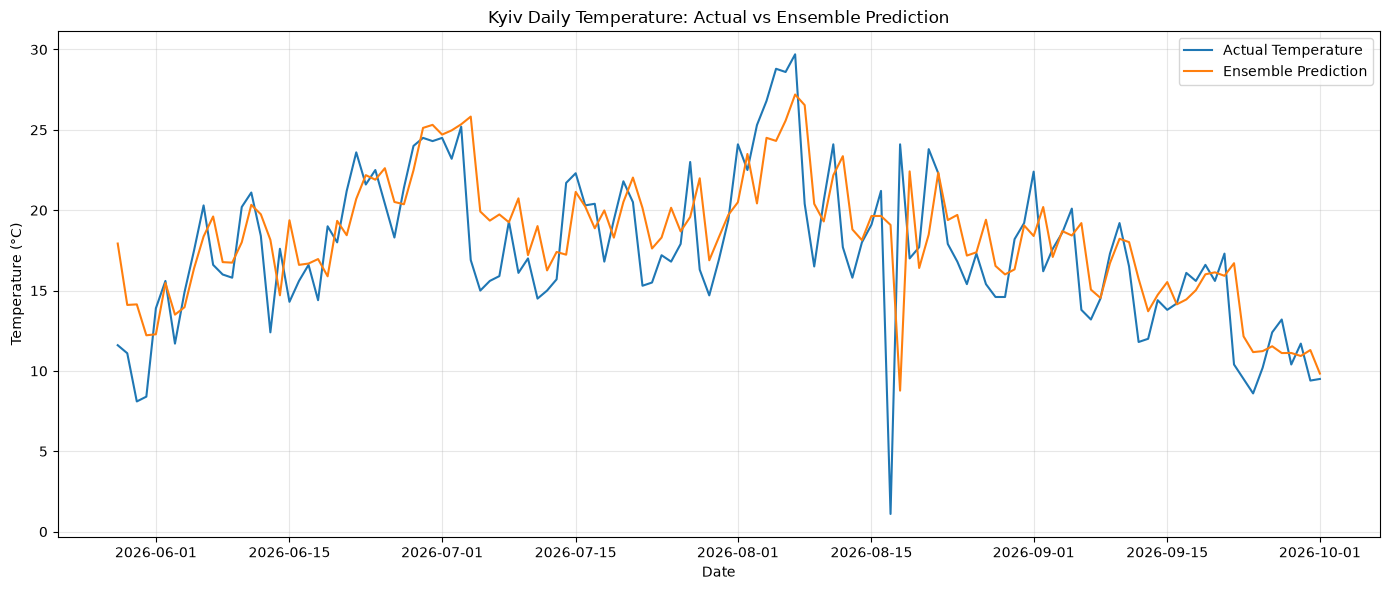

In [145]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual Temperature"
)

plt.plot(
    y_test.index,
    ensemble_test_pred,
    label="Ensemble Prediction"
)

plt.title("Kyiv Daily Temperature: Actual vs Ensemble Prediction")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

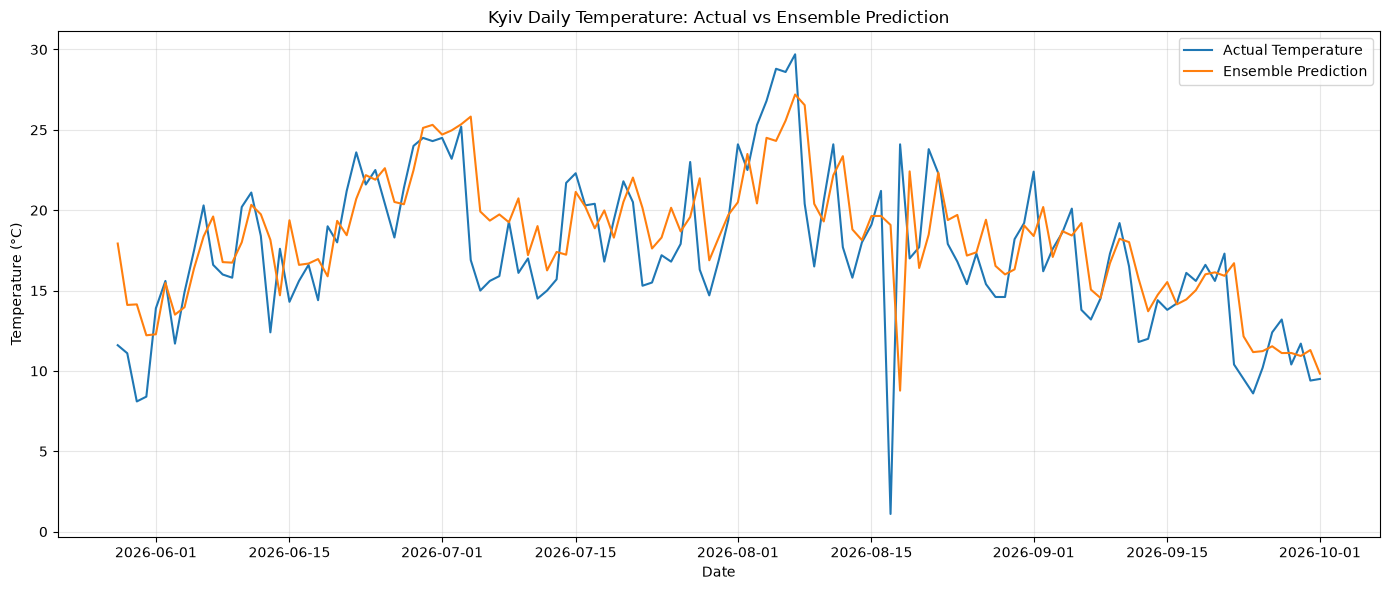

In [146]:
os.makedirs("../outputs/figures", exist_ok=True)

plt.figure(figsize=(14, 6))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual Temperature"
)

plt.plot(
    y_test.index,
    ensemble_test_pred,
    label="Ensemble Prediction"
)

plt.title("Kyiv Daily Temperature: Actual vs Ensemble Prediction")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/kyiv_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [148]:
# Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,lag_1,0.565120
1,rolling_7,0.383145
2,lag_2,0.011200
3,cos_day_of_year,0.011011
4,rolling_14,0.010470
5,lag_7,0.005006
6,lag_14,0.004422
7,day_of_year,0.003109
8,day_of_week,0.003095
9,sin_day_of_year,0.003079


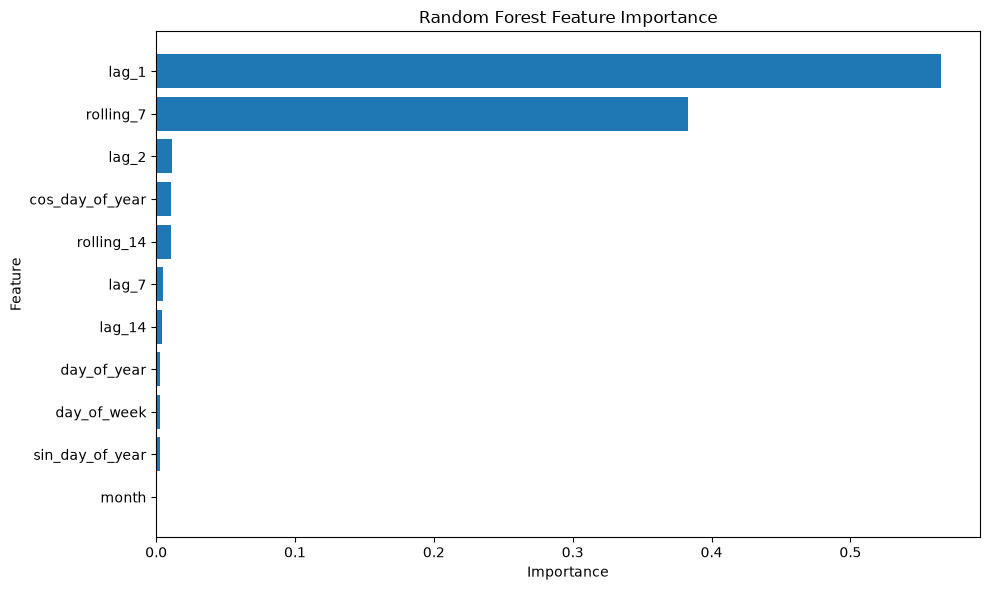

In [149]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [150]:
plt.savefig(
    "../outputs/figures/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [151]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance_Mean": permutation_result.importances_mean,
    "Importance_Std": permutation_result.importances_std
})

permutation_importance_df = permutation_importance_df.sort_values(
    "Importance_Mean",
    ascending=False
).reset_index(drop=True)

permutation_importance_df

,Feature,Importance_Mean,Importance_Std
0,lag_1,1.006550,0.093307
1,rolling_7,0.350310,0.037645
2,lag_7,0.021520,0.010643
3,sin_day_of_year,0.003907,0.007935
4,month,-0.000005,0.001333
5,day_of_year,-0.001018,0.004498
6,day_of_week,-0.001090,0.021212
7,lag_2,-0.012550,0.017411
8,cos_day_of_year,-0.026936,0.026543
9,lag_14,-0.027093,0.015759


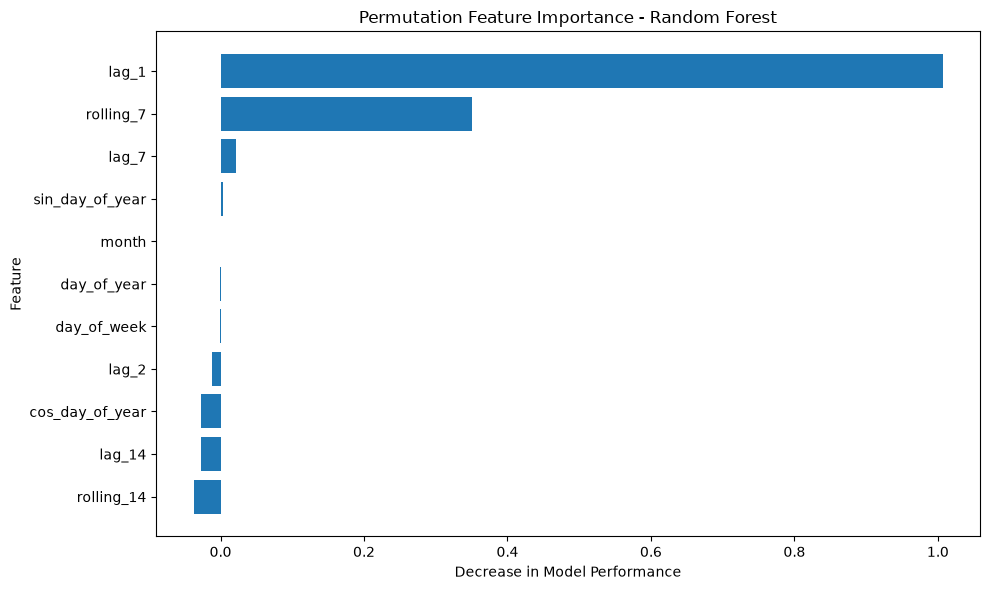

In [152]:
plt.figure(figsize=(10, 6))

plt.barh(
    permutation_importance_df["Feature"],
    permutation_importance_df["Importance_Mean"]
)

plt.gca().invert_yaxis()

plt.title("Permutation Feature Importance - Random Forest")
plt.xlabel("Decrease in Model Performance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [153]:
from sklearn.ensemble import IsolationForest

anomaly_features = [
    "temperature_celsius",
    "precip_mm",
    "humidity",
    "wind_kph",
    "pressure_mb",
    "visibility_km",
    "uv_index",
    "air_quality_PM2.5",
    "air_quality_PM10"
]

anomaly_df = weather[
    ["country", "location_name", "last_updated"] + anomaly_features
].copy()

print("Anomaly dataset shape:", anomaly_df.shape)
print("\nMissing values:")
print(anomaly_df[anomaly_features].isna().sum())

Anomaly dataset shape: (168591, 12)

Missing values:
temperature_celsius    0
precip_mm              0
humidity               0
wind_kph               0
pressure_mb            0
visibility_km          0
uv_index               0
air_quality_PM2.5      0
air_quality_PM10       0
dtype: int64


In [154]:
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(anomaly_df[anomaly_features])

anomaly_df["anomaly_score"] = isolation_forest.decision_function(
    anomaly_df[anomaly_features]
)

anomaly_df["anomaly"] = isolation_forest.predict(
    anomaly_df[anomaly_features]
)

anomaly_df["anomaly_label"] = anomaly_df["anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

print(anomaly_df["anomaly_label"].value_counts())

anomaly_label
Normal     166905
Anomaly      1686
Name: count, dtype: int64


In [155]:
top_anomalies = anomaly_df[
    anomaly_df["anomaly"] == -1
].sort_values(
    "anomaly_score"
).head(20)

top_anomalies

,country,location_name,last_updated,temperature_celsius,precip_mm,humidity,wind_kph,pressure_mb,visibility_km,uv_index,air_quality_PM2.5,air_quality_PM10,anomaly_score,anomaly,anomaly_label
74664,Kuwait,Kuwait City,2025-07-01 12:00:00,43.7,0.0,7,42.1,996.0,2.8,8.4,353.165,2315.65,-0.150579,-1,Anomaly
74657,Kuwait,Kuwait City,2025-06-24 11:45:00,44.8,0.0,6,40.7,997.0,4.0,9.5,214.415,1467.97,-0.143478,-1,Anomaly
74652,Kuwait,Kuwait City,2025-06-19 12:15:00,41.4,0.0,5,43.2,1000.0,5.0,9.4,232.545,1743.62,-0.142476,-1,Anomaly
74386,Kuwait,Kuwait City,2024-09-26 12:30:00,39.7,0.0,9,38.9,1003.0,2.0,9.0,207.200,1791.91,-0.138967,-1,Anomaly
74668,Kuwait,Kuwait City,2025-07-05 11:45:00,41.2,0.0,7,37.1,999.0,6.0,8.9,211.455,1471.31,-0.138492,-1,Anomaly
74636,Kuwait,Kuwait City,2025-06-03 12:00:00,39.2,0.0,9,43.6,1003.0,5.0,10.2,204.240,1547.16,-0.137225,-1,Anomaly
74651,Kuwait,Kuwait City,2025-06-18 12:15:00,43.1,0.0,6,42.5,1000.0,6.0,9.9,159.840,1133.68,-0.136007,-1,Anomaly
74698,Kuwait,Kuwait City,2025-08-04 11:30:00,44.9,0.0,9,36.0,1000.0,6.0,9.8,227.365,1471.31,-0.134742,-1,Anomaly
74619,Kuwait,Kuwait City,2025-05-17 11:45:00,37.1,0.0,6,38.5,1007.0,1.2,9.4,194.250,1147.56,-0.133248,-1,Anomaly
74373,Kuwait,Kuwait City,2024-09-13 15:30:00,43.8,0.0,9,38.2,999.0,4.0,10.0,133.940,1533.46,-0.131461,-1,Anomaly


In [156]:
anomaly_by_country = (
    anomaly_df[anomaly_df["anomaly"] == -1]
    .groupby("country")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

print("Top 15 countries by anomaly count:")
print(anomaly_by_country)

Top 15 countries by anomaly count:
country
Saudi Arabia            430
Kuwait                  245
India                   146
Sudan                   125
Chile                    96
Chad                     78
Qatar                    65
China                    63
Bahrain                  59
Burkina Faso             51
Mauritania               48
Indonesia                48
United Arab Emirates     27
Nigeria                  21
Iceland                  14
dtype: int64


In [157]:
anomaly_by_location = (
    anomaly_df[anomaly_df["anomaly"] == -1]
    .groupby(["country", "location_name"])
    .size()
    .sort_values(ascending=False)
    .head(15)
)

print("Top 15 locations by anomaly count:")
print(anomaly_by_location)

Top 15 locations by anomaly count:
country               location_name
Saudi Arabia          Riyadh           430
Kuwait                Kuwait City      244
India                 New Delhi        146
Chile                 Santiago          96
Sudan                 Juba              95
Chad                  N'djamena         78
Qatar                 Doha              65
China                 Beijing           63
Bahrain               Manama            59
Burkina Faso          Ouagadougou       51
Mauritania            Nouakchott        48
Indonesia             Jakarta           48
Sudan                 Khartoum          30
United Arab Emirates  Abu Dhabi         27
Nigeria               Abuja             21
dtype: int64


In [158]:
country_anomaly_rate = (
    anomaly_df
    .groupby("country")
    .agg(
        total_observations=("anomaly", "size"),
        anomalies=("anomaly", lambda x: (x == -1).sum())
    )
)

country_anomaly_rate["anomaly_rate_percent"] = (
    country_anomaly_rate["anomalies"] /
    country_anomaly_rate["total_observations"] * 100
)

country_anomaly_rate = country_anomaly_rate.sort_values(
    "anomaly_rate_percent",
    ascending=False
)

print("Countries with highest anomaly rates:")
print(country_anomaly_rate.head(15))

Countries with highest anomaly rates:
                      total_observations  anomalies  anomaly_rate_percent
country                                                                  
Saudi Arabia                         865        430             49.710983
Kuwait                               865        245             28.323699
India                                864        146             16.898148
Chile                                863         96             11.123986
Chad                                 867         78              8.996540
Qatar                                864         65              7.523148
China                                864         63              7.291667
Sudan                               1727        125              7.237985
Bahrain                              866         59              6.812933
Burkina Faso                         866         51              5.889145
Mauritania                           865         48              5.549133


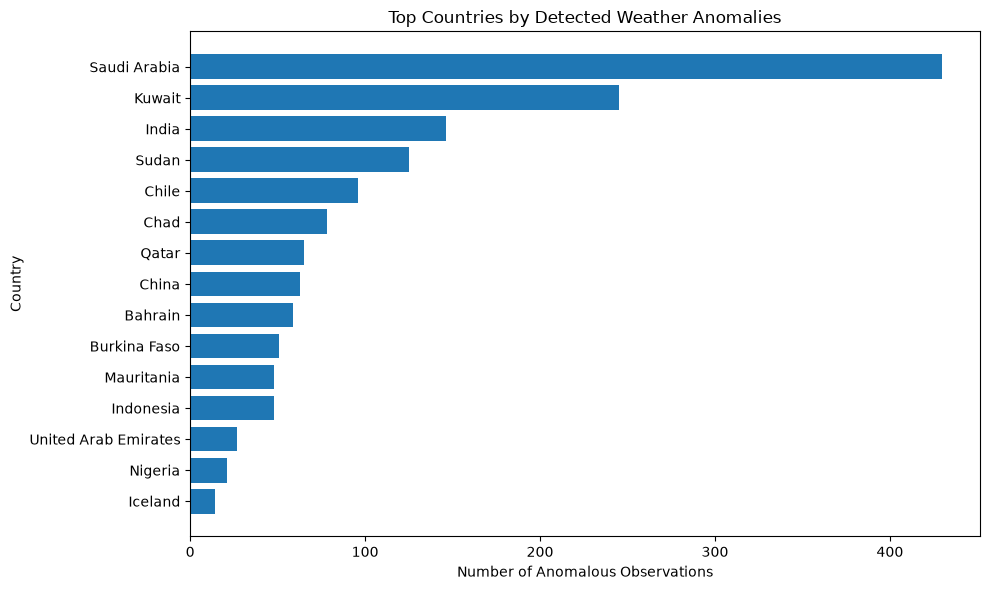

In [159]:
top_anomaly_countries = anomaly_by_country.sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_anomaly_countries.index,
    top_anomaly_countries.values
)

plt.title("Top Countries by Detected Weather Anomalies")
plt.xlabel("Number of Anomalous Observations")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [160]:
plt.savefig(
    "../outputs/figures/top_anomaly_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [161]:
anomaly_summary = (
    anomaly_df
    .groupby("anomaly_label")[anomaly_features]
    .mean()
    .T
)

anomaly_summary

anomaly_label,Anomaly,Normal
temperature_celsius,28.667260,21.385604
precip_mm,0.366388,0.130056
humidity,31.648280,67.387442
wind_kph,20.634816,12.597140
pressure_mb,1009.442467,1014.035134
visibility_km,7.809846,9.520722
uv_index,6.224021,3.039349
air_quality_PM2.5,192.953190,20.854504
air_quality_PM10,940.670109,36.207246


In [162]:
normal_means = anomaly_df[
    anomaly_df["anomaly_label"] == "Normal"
][anomaly_features].mean()

anomaly_means = anomaly_df[
    anomaly_df["anomaly_label"] == "Anomaly"
][anomaly_features].mean()

anomaly_comparison = pd.DataFrame({
    "Normal_Mean": normal_means,
    "Anomaly_Mean": anomaly_means
})

anomaly_comparison["Difference"] = (
    anomaly_comparison["Anomaly_Mean"] -
    anomaly_comparison["Normal_Mean"]
)

anomaly_comparison

,Normal_Mean,Anomaly_Mean,Difference
temperature_celsius,21.385604,28.667260,7.281656
precip_mm,0.130056,0.366388,0.236332
humidity,67.387442,31.648280,-35.739162
wind_kph,12.597140,20.634816,8.037676
pressure_mb,1014.035134,1009.442467,-4.592666
visibility_km,9.520722,7.809846,-1.710876
uv_index,3.039349,6.224021,3.184673
air_quality_PM2.5,20.854504,192.953190,172.098687
air_quality_PM10,36.207246,940.670109,904.462863


In [163]:
country_climate = (
    weather
    .groupby("country")
    .agg(
        mean_temperature=("temperature_celsius", "mean"),
        min_temperature=("temperature_celsius", "min"),
        max_temperature=("temperature_celsius", "max"),
        mean_precipitation=("precip_mm", "mean"),
        mean_humidity=("humidity", "mean"),
        observations=("temperature_celsius", "size")
    )
    .sort_values("mean_temperature", ascending=False)
)

country_climate.head(15)

,mean_temperature,min_temperature,max_temperature,mean_precipitation,mean_humidity,observations
country,,,,,,
Saudi Arabien,45.000000,45.0,45.0,0.000000,7.000000,1
Marrocos,40.300000,40.3,40.3,0.000000,14.000000,1
Turkménistan,37.800000,37.8,37.8,0.000000,11.000000,1
Турция,34.000000,34.0,34.0,0.000000,44.000000,1
Qatar,32.971759,15.2,46.3,0.002824,40.114583,864
United Arab Emirates,32.545497,18.0,46.4,0.000404,44.980370,866
Cambodia,32.101040,22.6,39.9,0.140416,58.994220,865
Oman,31.830716,18.0,46.3,0.003603,53.032333,866
Kuwait,31.619769,7.3,49.2,0.008023,27.537572,865


In [164]:
country_climate.sort_values(
    "mean_temperature"
).head(15)

,mean_temperature,min_temperature,max_temperature,mean_precipitation,mean_humidity,observations
country,,,,,,
Iceland,5.755208,-25.4,18.1,0.164086,79.905093,864
Mongolia,6.017688,-29.8,34.3,0.045202,50.157225,865
Canada,6.609375,-25.0,29.2,0.187465,82.564815,864
Norway,8.415385,-19.6,26.2,0.093657,77.440357,897
Andorra,9.065704,-14.4,28.9,0.104319,65.471132,866
United States of America,9.429002,-2.8,26.1,0.048921,87.609049,862
Finland,9.493649,-23.9,29.1,0.080566,75.349885,866
Russia,9.611087,-25.8,32.2,0.079707,69.533696,920
Estonia,9.794329,-17.6,32.3,0.088438,75.474537,864


In [165]:
country_climate_reliable = country_climate[
    country_climate["observations"] >= 100
].copy()

print("Countries with at least 100 observations:")
print(len(country_climate_reliable))

Countries with at least 100 observations:
186


In [166]:
print("Warmest represented countries:")
print(
    country_climate_reliable
    .sort_values("mean_temperature", ascending=False)
    .head(15)
)

Warmest represented countries:
                      mean_temperature  min_temperature  max_temperature  \
country                                                                    
Qatar                        32.971759             15.2             46.3   
United Arab Emirates         32.545497             18.0             46.4   
Cambodia                     32.101040             22.6             39.9   
Oman                         31.830716             18.0             46.3   
Kuwait                       31.619769              7.3             49.2   
Djibouti                     31.515991             23.3             47.1   
Bangladesh                   31.283699             18.5             42.2   
Saudi Arabia                 31.122197              6.1             46.3   
Thailand                     31.100347             21.1             39.3   
Malaysia                     30.659422             22.8             36.4   
India                        30.640972             10.1  

In [167]:
print("Coolest represented countries:")
print(
    country_climate_reliable
    .sort_values("mean_temperature")
    .head(15)
)

Coolest represented countries:
                          mean_temperature  min_temperature  max_temperature  \
country                                                                        
Iceland                           5.755208            -25.4             18.1   
Mongolia                          6.017688            -29.8             34.3   
Canada                            6.609375            -25.0             29.2   
Norway                            8.415385            -19.6             26.2   
Andorra                           9.065704            -14.4             28.9   
United States of America          9.429002             -2.8             26.1   
Finland                           9.493649            -23.9             29.1   
Russia                            9.611087            -25.8             32.2   
Estonia                           9.794329            -17.6             32.3   
Lithuania                        10.096416            -23.9             31.2   
Belarus  

In [168]:
latitude_climate = (
    weather
    .groupby(pd.cut(
        weather["latitude"],
        bins=[-90, -60, -30, 0, 30, 60, 90]
    ))
    .agg(
        mean_temperature=("temperature_celsius", "mean"),
        mean_precipitation=("precip_mm", "mean"),
        mean_humidity=("humidity", "mean"),
        observations=("temperature_celsius", "size")
    )
)

latitude_climate

,mean_temperature,mean_precipitation,mean_humidity,observations
latitude,,,,
"(-60, -30]",13.546369,0.105268,77.115865,4324
"(-30, 0]",23.518736,0.157981,68.913869,32323
"(0, 30]",26.396669,0.180064,69.922158,65800
"(30, 60]",16.287400,0.073006,62.158339,64381
"(60, 90]",7.615825,0.121809,77.716393,1763


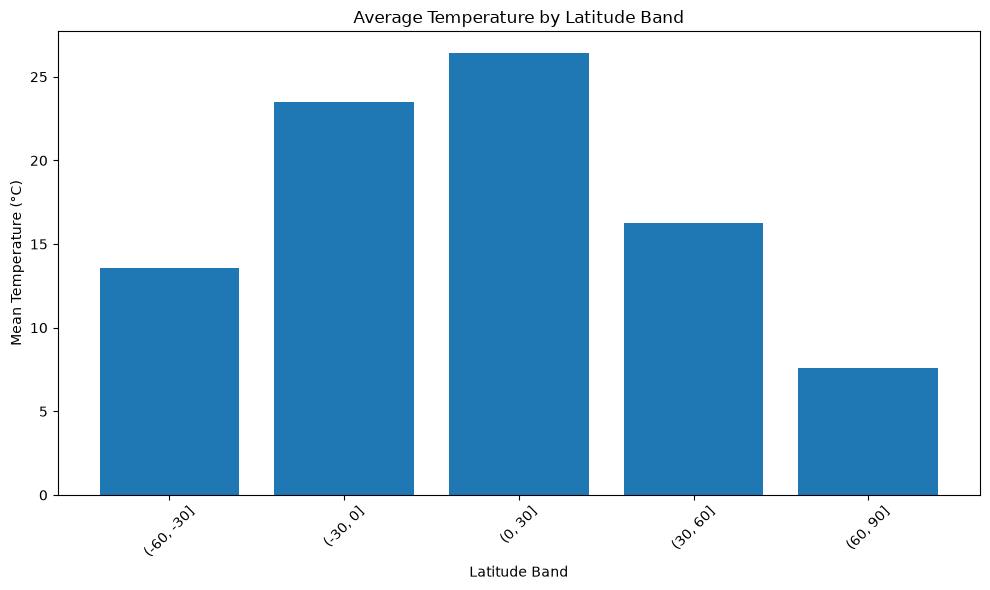

In [169]:
plt.figure(figsize=(10, 6))

plt.bar(
    latitude_climate.index.astype(str),
    latitude_climate["mean_temperature"]
)

plt.title("Average Temperature by Latitude Band")
plt.xlabel("Latitude Band")
plt.ylabel("Mean Temperature (°C)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

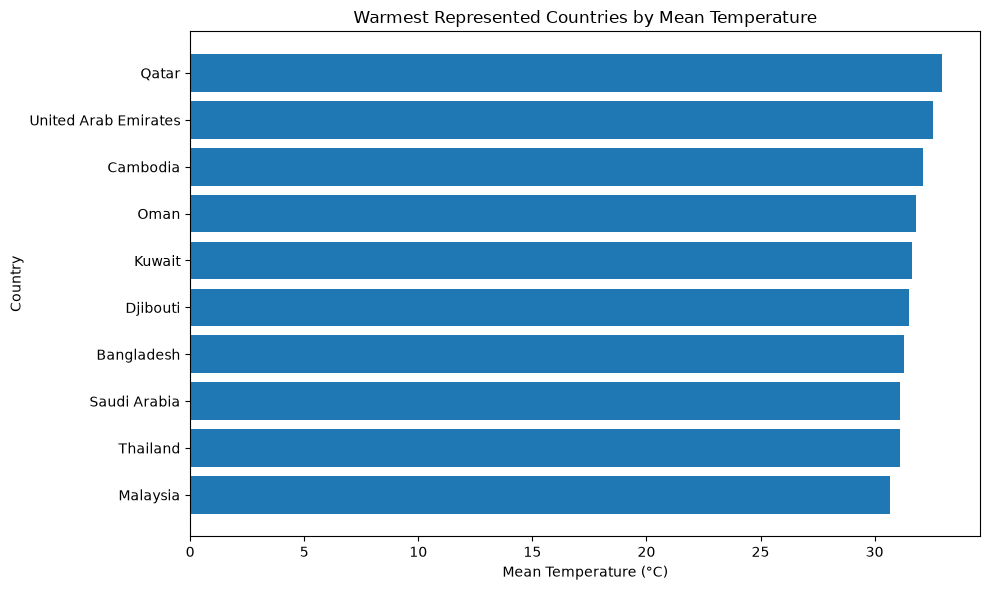

In [170]:
# Select the 10 warmest and 10 coolest represented countries
warmest_10 = (
    country_climate_reliable
    .sort_values("mean_temperature", ascending=False)
    .head(10)
    .sort_values("mean_temperature")
)

coolest_10 = (
    country_climate_reliable
    .sort_values("mean_temperature")
    .head(10)
    .sort_values("mean_temperature", ascending=False)
)

plt.figure(figsize=(10, 6))

plt.barh(
    warmest_10.index,
    warmest_10["mean_temperature"]
)

plt.title("Warmest Represented Countries by Mean Temperature")
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Country")
plt.tight_layout()

plt.savefig(
    "../outputs/figures/warmest_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

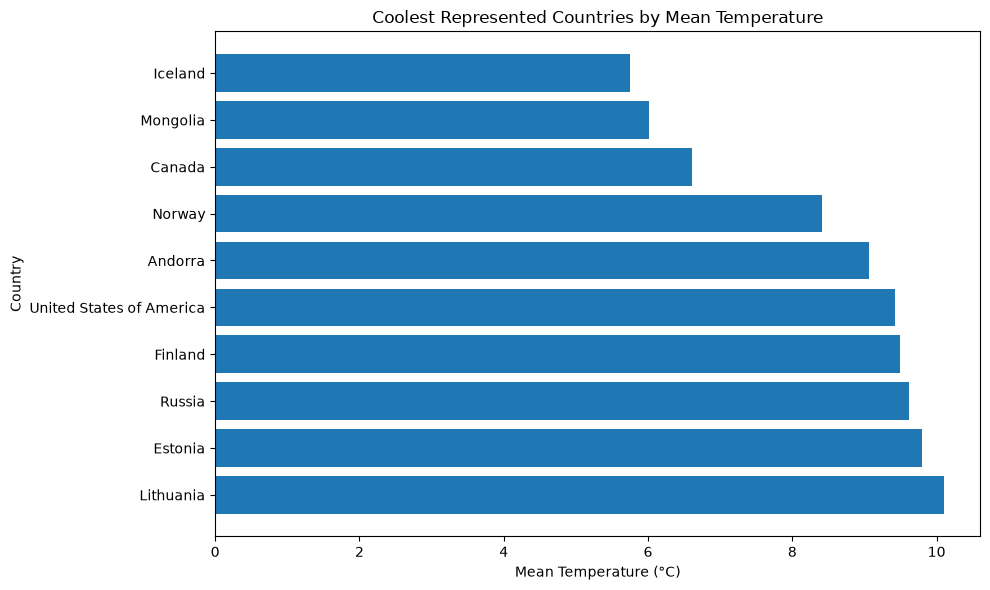

In [171]:
plt.figure(figsize=(10, 6))

plt.barh(
    coolest_10.index,
    coolest_10["mean_temperature"]
)

plt.title("Coolest Represented Countries by Mean Temperature")
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Country")
plt.tight_layout()

plt.savefig(
    "../outputs/figures/coolest_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

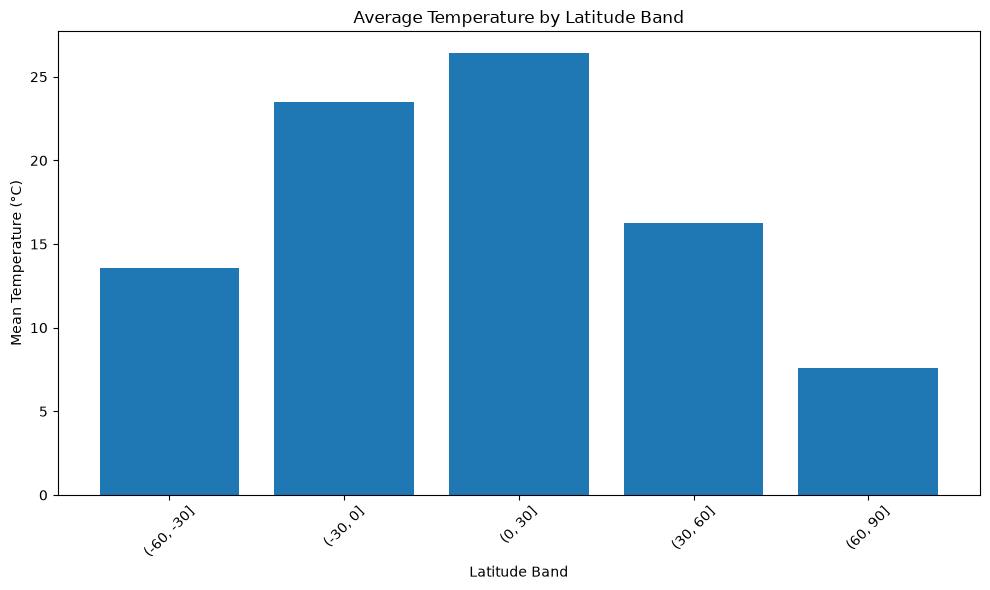

In [172]:
plt.figure(figsize=(10, 6))

plt.bar(
    latitude_climate.index.astype(str),
    latitude_climate["mean_temperature"]
)

plt.title("Average Temperature by Latitude Band")
plt.xlabel("Latitude Band")
plt.ylabel("Mean Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/temperature_by_latitude_band.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [173]:
air_quality_analysis = weather.copy()

# Temperature categories
air_quality_analysis["temperature_group"] = pd.cut(
    air_quality_analysis["temperature_celsius"],
    bins=[-np.inf, 10, 20, 30, np.inf],
    labels=["Cold (<10°C)", "Mild (10–20°C)", "Warm (20–30°C)", "Hot (>30°C)"]
)

# Humidity categories
air_quality_analysis["humidity_group"] = pd.cut(
    air_quality_analysis["humidity"],
    bins=[-np.inf, 40, 60, 80, np.inf],
    labels=["Low (<40%)", "Moderate (40–60%)", "High (60–80%)", "Very High (>80%)"]
)

# Wind categories
air_quality_analysis["wind_group"] = pd.cut(
    air_quality_analysis["wind_kph"],
    bins=[-np.inf, 10, 20, 40, np.inf],
    labels=["Low (<10 kph)", "Moderate (10–20 kph)", "High (20–40 kph)", "Very High (>40 kph)"]
)

print(air_quality_analysis[
    ["temperature_group", "humidity_group", "wind_group"]
].head())

  temperature_group     humidity_group            wind_group
0    Mild (10–20°C)   Very High (>80%)      High (20–40 kph)
1    Mild (10–20°C)   Very High (>80%)  Moderate (10–20 kph)
2    Mild (10–20°C)      High (60–80%)      High (20–40 kph)
3    Mild (10–20°C)  Moderate (40–60%)  Moderate (10–20 kph)
4    Mild (10–20°C)  Moderate (40–60%)      High (20–40 kph)


In [174]:
temperature_aq = (
    air_quality_analysis
    .groupby("temperature_group", observed=True)
    .agg(
        PM2_5=("air_quality_PM2.5", "mean"),
        PM10=("air_quality_PM10", "mean"),
        Ozone=("air_quality_Ozone", "mean"),
        NO2=("air_quality_Nitrogen_dioxide", "mean"),
        SO2=("air_quality_Sulphur_dioxide", "mean"),
        CO=("air_quality_Carbon_Monoxide", "mean"),
        observations=("temperature_celsius", "size")
    )
)

temperature_aq

,PM2_5,PM10,Ozone,NO2,SO2,CO,observations
temperature_group,,,,,,,
Cold (<10°C),24.314876,29.508318,45.644889,23.192376,13.737614,501.244632,21335
Mild (10–20°C),19.722157,35.081635,53.095627,17.252128,10.876934,403.486571,37963
Warm (20–30°C),19.507468,39.777789,56.714470,8.674624,6.367359,358.579550,85989
Hot (>30°C),36.952550,96.435106,80.885578,19.375057,15.641178,576.311345,23304


In [175]:
humidity_aq = (
    air_quality_analysis
    .groupby("humidity_group", observed=True)
    .agg(
        PM2_5=("air_quality_PM2.5", "mean"),
        PM10=("air_quality_PM10", "mean"),
        Ozone=("air_quality_Ozone", "mean"),
        NO2=("air_quality_Nitrogen_dioxide", "mean"),
        SO2=("air_quality_Sulphur_dioxide", "mean"),
        CO=("air_quality_Carbon_Monoxide", "mean"),
        observations=("humidity", "size")
    )
)

humidity_aq

,PM2_5,PM10,Ozone,NO2,SO2,CO,observations
humidity_group,,,,,,,
Low (<40%),37.168658,119.056581,78.642671,18.110901,16.300610,504.611641,27098
Moderate (40–60%),26.356944,46.528616,68.624600,16.405942,13.187279,451.564345,29777
High (60–80%),19.840487,31.052839,55.109254,12.510165,8.123577,413.287551,54044
Very High (>80%),16.329479,23.221714,45.055882,11.995460,5.975443,361.006403,57672


In [176]:
wind_aq = (
    air_quality_analysis
    .groupby("wind_group", observed=True)
    .agg(
        PM2_5=("air_quality_PM2.5", "mean"),
        PM10=("air_quality_PM10", "mean"),
        Ozone=("air_quality_Ozone", "mean"),
        NO2=("air_quality_Nitrogen_dioxide", "mean"),
        SO2=("air_quality_Sulphur_dioxide", "mean"),
        CO=("air_quality_Carbon_Monoxide", "mean"),
        observations=("wind_kph", "size")
    )
)

wind_aq

,PM2_5,PM10,Ozone,NO2,SO2,CO,observations
wind_group,,,,,,,
Low (<10 kph),23.857463,35.126491,53.075032,16.725648,10.968316,495.583852,78738
Moderate (10–20 kph),21.984616,47.094818,60.954679,13.664505,9.852237,396.113171,58745
High (20–40 kph),20.615871,68.066896,63.747492,7.370248,5.696621,257.936796,30138
Very High (>40 kph),15.199685,46.768323,72.427526,5.567564,4.082712,217.755433,970


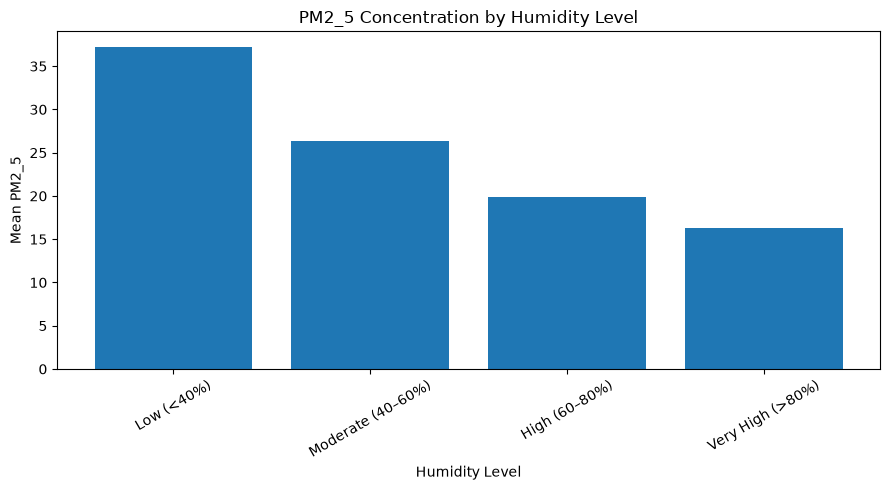

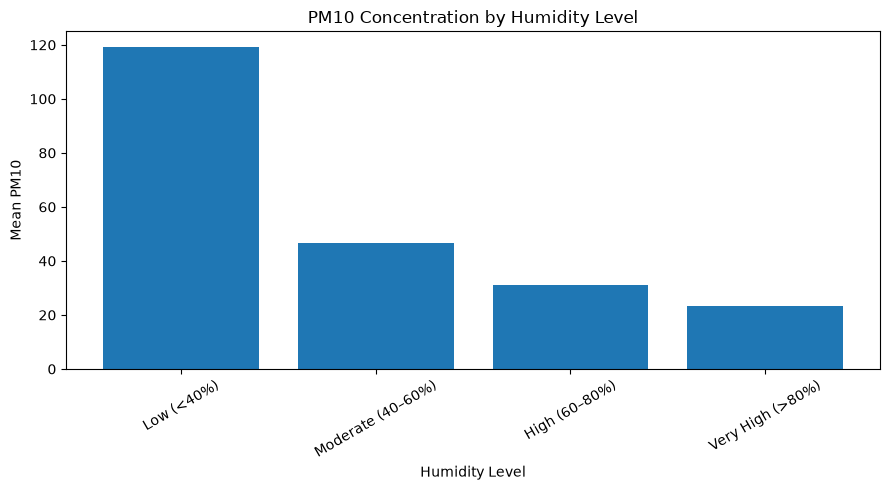

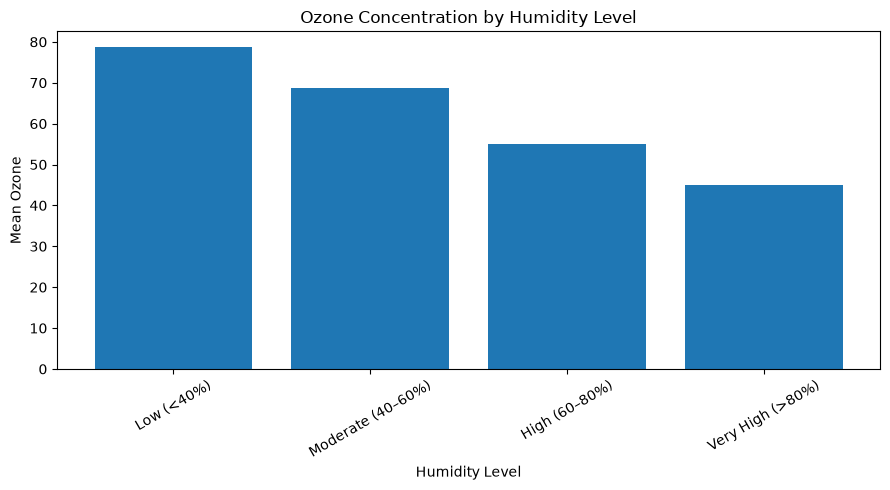

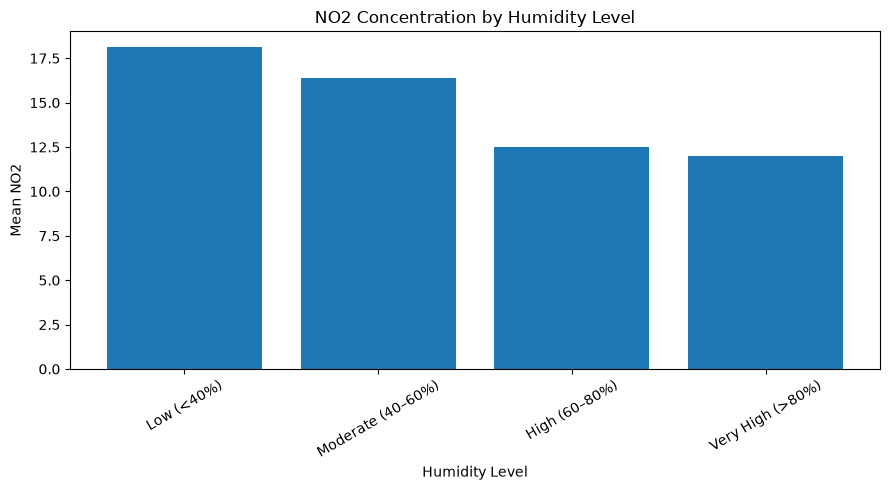

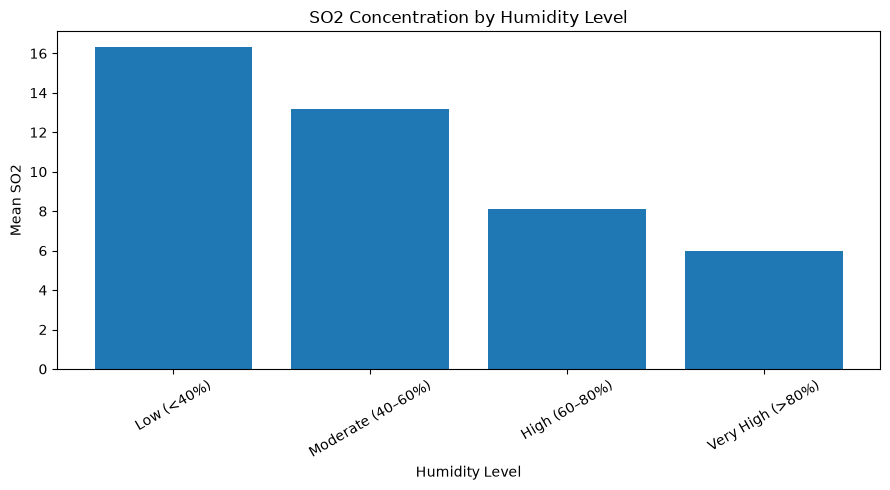

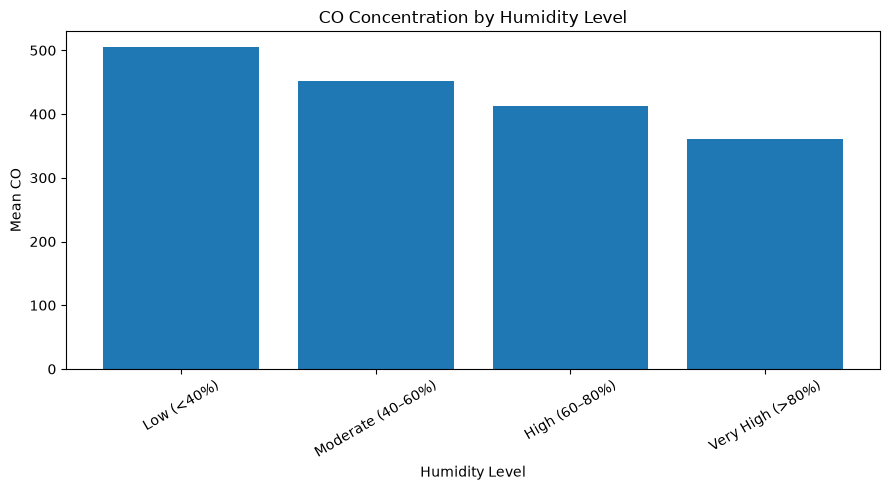

In [177]:
pollutants = ["PM2_5", "PM10", "Ozone", "NO2", "SO2", "CO"]

for pollutant in pollutants:
    plt.figure(figsize=(9, 5))

    plt.bar(
        humidity_aq.index.astype(str),
        humidity_aq[pollutant]
    )

    plt.title(f"{pollutant} Concentration by Humidity Level")
    plt.xlabel("Humidity Level")
    plt.ylabel(f"Mean {pollutant}")
    plt.xticks(rotation=30)
    plt.tight_layout()

    plt.savefig(
        f"../outputs/figures/{pollutant.lower()}_by_humidity.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

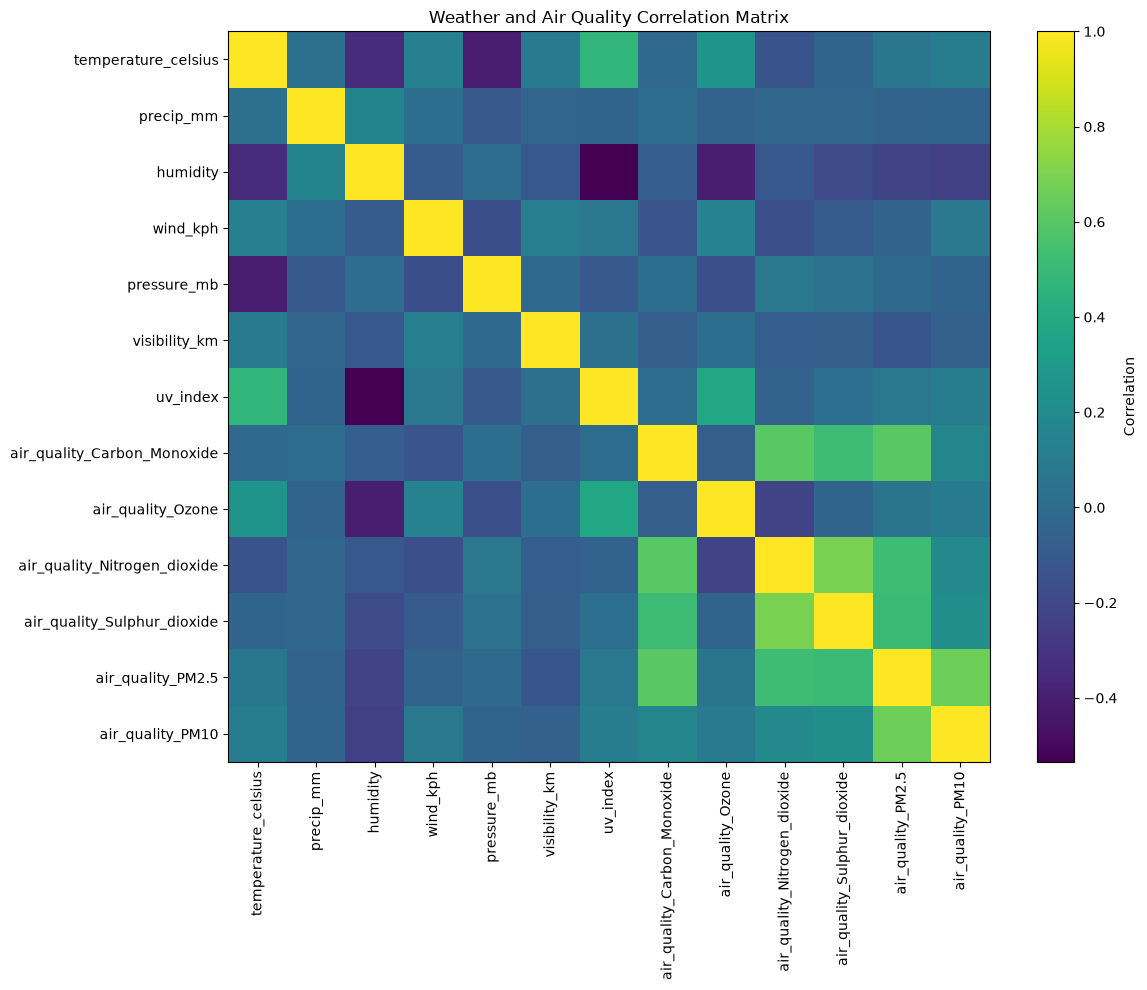

In [178]:
weather_aq_columns = [
    "temperature_celsius",
    "precip_mm",
    "humidity",
    "wind_kph",
    "pressure_mb",
    "visibility_km",
    "uv_index",
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5",
    "air_quality_PM10"
]

weather_aq_corr = weather[weather_aq_columns].corr()

plt.figure(figsize=(12, 10))

plt.imshow(weather_aq_corr, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(weather_aq_corr.columns)),
    weather_aq_corr.columns,
    rotation=90
)

plt.yticks(
    range(len(weather_aq_corr.columns)),
    weather_aq_corr.columns
)

plt.title("Weather and Air Quality Correlation Matrix")
plt.tight_layout()

plt.savefig(
    "../outputs/figures/weather_air_quality_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [179]:
print("Latitude range:")
print(weather["latitude"].min(), "to", weather["latitude"].max())

print("\nLongitude range:")
print(weather["longitude"].min(), "to", weather["longitude"].max())

print("\nCountries:")
print(weather["country"].nunique())

print("\nLocations:")
print(weather["location_name"].nunique())

Latitude range:
-41.3 to 65.3

Longitude range:
-175.2 to 179.22

Countries:
211

Locations:
268


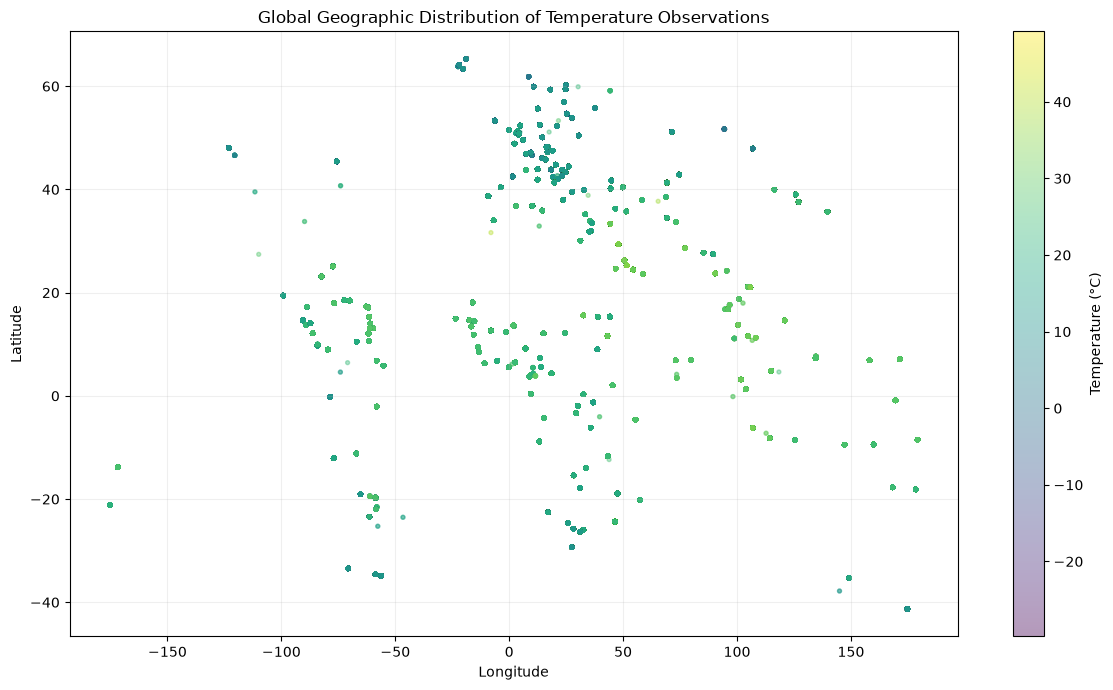

In [180]:
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    weather["longitude"],
    weather["latitude"],
    c=weather["temperature_celsius"],
    s=8,
    alpha=0.4
)

plt.colorbar(scatter, label="Temperature (°C)")

plt.title("Global Geographic Distribution of Temperature Observations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/global_temperature_spatial_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

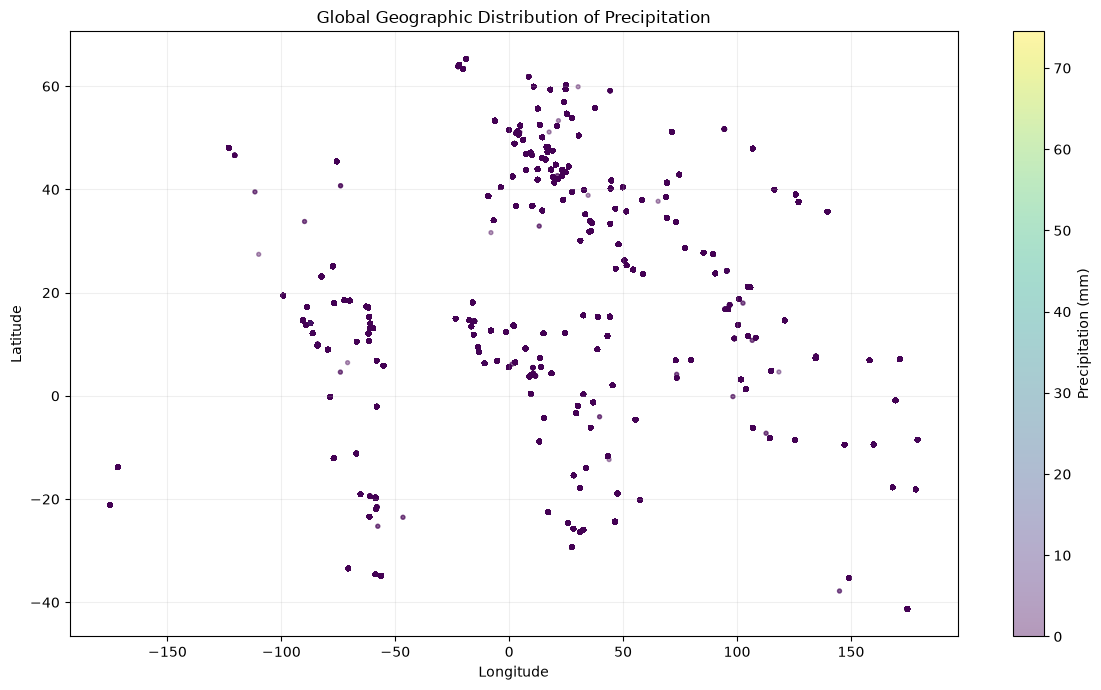

In [181]:
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    weather["longitude"],
    weather["latitude"],
    c=weather["precip_mm"],
    s=8,
    alpha=0.4
)

plt.colorbar(scatter, label="Precipitation (mm)")

plt.title("Global Geographic Distribution of Precipitation")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/global_precipitation_spatial_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [182]:
location_spatial = (
    weather
    .groupby(["country", "location_name"])
    .agg(
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean"),
        mean_temperature=("temperature_celsius", "mean"),
        mean_precipitation=("precip_mm", "mean"),
        mean_PM2_5=("air_quality_PM2.5", "mean"),
        mean_PM10=("air_quality_PM10", "mean"),
        mean_ozone=("air_quality_Ozone", "mean"),
        observations=("temperature_celsius", "size")
    )
    .reset_index()
)

print("Location-level dataset shape:", location_spatial.shape)
location_spatial.head()

Location-level dataset shape: (286, 10)


,country,location_name,latitude,longitude,mean_temperature,mean_precipitation,mean_PM2_5,mean_PM10,mean_ozone,observations
0,Afghanistan,Kabul,34.517230,69.182770,19.983256,0.031201,18.024706,40.191103,108.876559,866
1,Albania,Tirana,41.327902,19.819077,19.728671,0.120301,14.609457,19.621618,69.475491,865
2,Algeria,Algiers,36.762605,3.050504,20.747222,0.048808,18.192998,32.878582,60.324537,864
3,Andorra,Andorra La Vella,42.500000,1.517230,9.065704,0.104319,4.793611,8.871510,68.396998,866
4,Angola,Luanda,-8.838573,13.233694,25.255196,0.030127,28.513106,42.587148,74.356928,866


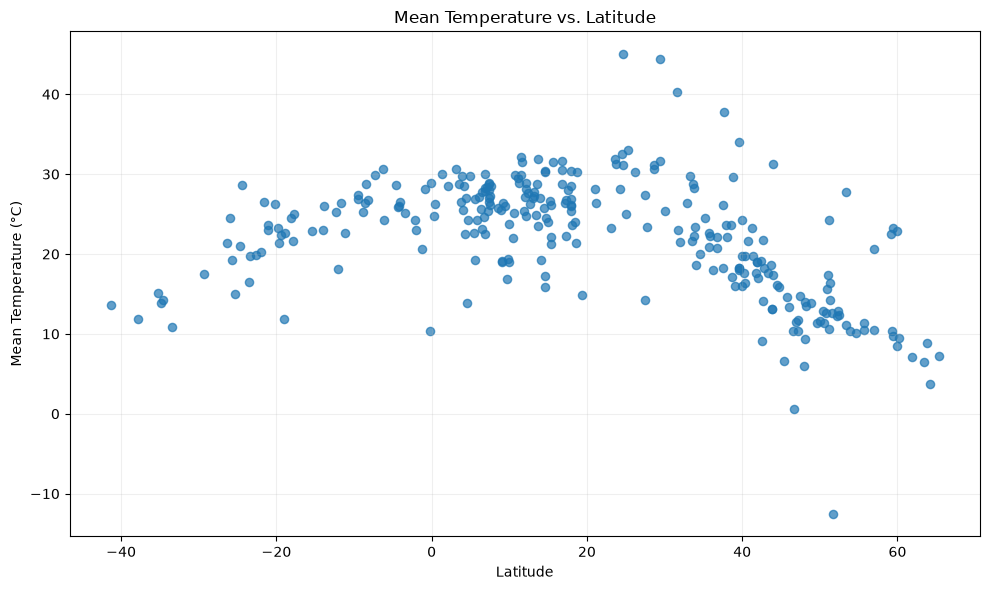

In [183]:
plt.figure(figsize=(10, 6))

plt.scatter(
    location_spatial["latitude"],
    location_spatial["mean_temperature"],
    s=35,
    alpha=0.7
)

plt.title("Mean Temperature vs. Latitude")
plt.xlabel("Latitude")
plt.ylabel("Mean Temperature (°C)")
plt.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/temperature_vs_latitude.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [184]:
pollution_hotspots = (
    location_spatial[
        location_spatial["observations"] >= 100
    ]
    .sort_values("mean_PM2_5", ascending=False)
)

print("Top locations by mean PM2.5:")
print(
    pollution_hotspots[
        [
            "country",
            "location_name",
            "latitude",
            "longitude",
            "mean_PM2_5",
            "mean_PM10",
            "observations"
        ]
    ].head(15)
)

Top locations by mean PM2.5:
                  country location_name   latitude   longitude  mean_PM2_5  \
216          Saudi Arabia        Riyadh  24.640672   46.772353  134.277561   
50                  Chile      Santiago -33.450000  -70.667232  134.015359   
104             Indonesia       Jakarta  -6.213862  106.845886  129.537096   
51                  China       Beijing  39.929075  116.388570  115.648824   
102                 India     New Delhi  28.600000   77.200000  103.689161   
128                Kuwait   Kuwait City  29.367227   47.960000   91.707616   
275               Vietnam         Hanoi  21.032774  105.850000   69.489491   
153            Mauritania    Nouakchott  18.086978  -15.976055   65.381538   
13                Bahrain        Manama  26.236726   50.582602   63.753539   
14             Bangladesh         Dhaka  23.722605   90.408823   61.894468   
202                 Qatar          Doha  25.287231   51.532769   56.508727   
261  United Arab Emirates     Abu D

In [185]:
print("Top locations by mean PM10:")
print(
    pollution_hotspots
    .sort_values("mean_PM10", ascending=False)[
        [
            "country",
            "location_name",
            "latitude",
            "longitude",
            "mean_PM2_5",
            "mean_PM10",
            "observations"
        ]
    ].head(15)
)

Top locations by mean PM10:
                  country location_name   latitude   longitude  mean_PM2_5  \
216          Saudi Arabia        Riyadh  24.640672   46.772353  134.277561   
128                Kuwait   Kuwait City  29.367227   47.960000   91.707616   
153            Mauritania    Nouakchott  18.086978  -15.976055   65.381538   
102                 India     New Delhi  28.600000   77.200000  103.689161   
232                 Sudan          Juba  12.150000   24.450000   41.866489   
35           Burkina Faso   Ouagadougou  12.370252   -1.523951   36.546085   
13                Bahrain        Manama  26.236726   50.582602   63.753539   
202                 Qatar          Doha  25.287231   51.532769   56.508727   
49                   Chad     N'djamena  12.112603   15.049328   42.148766   
50                  Chile      Santiago -33.450000  -70.667232  134.015359   
233                 Sudan      Khartoum  15.588403   32.533529   42.118600   
104             Indonesia       Jaka

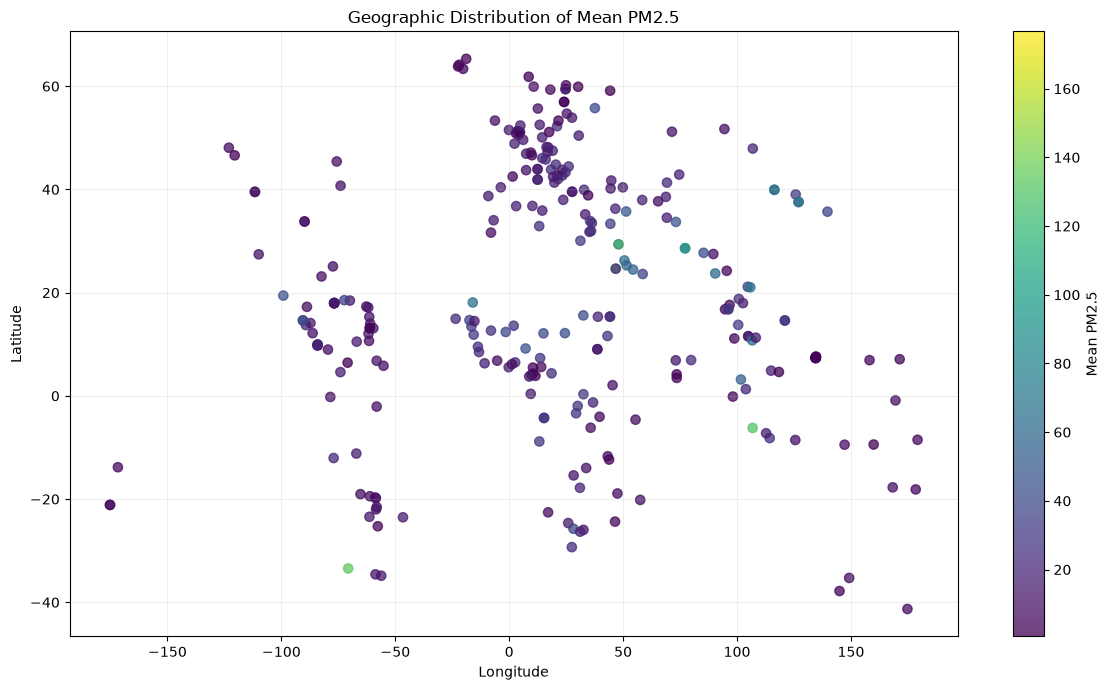

In [186]:
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    location_spatial["longitude"],
    location_spatial["latitude"],
    c=location_spatial["mean_PM2_5"],
    s=45,
    alpha=0.75
)

plt.colorbar(scatter, label="Mean PM2.5")

plt.title("Geographic Distribution of Mean PM2.5")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/geographic_mean_pm25.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

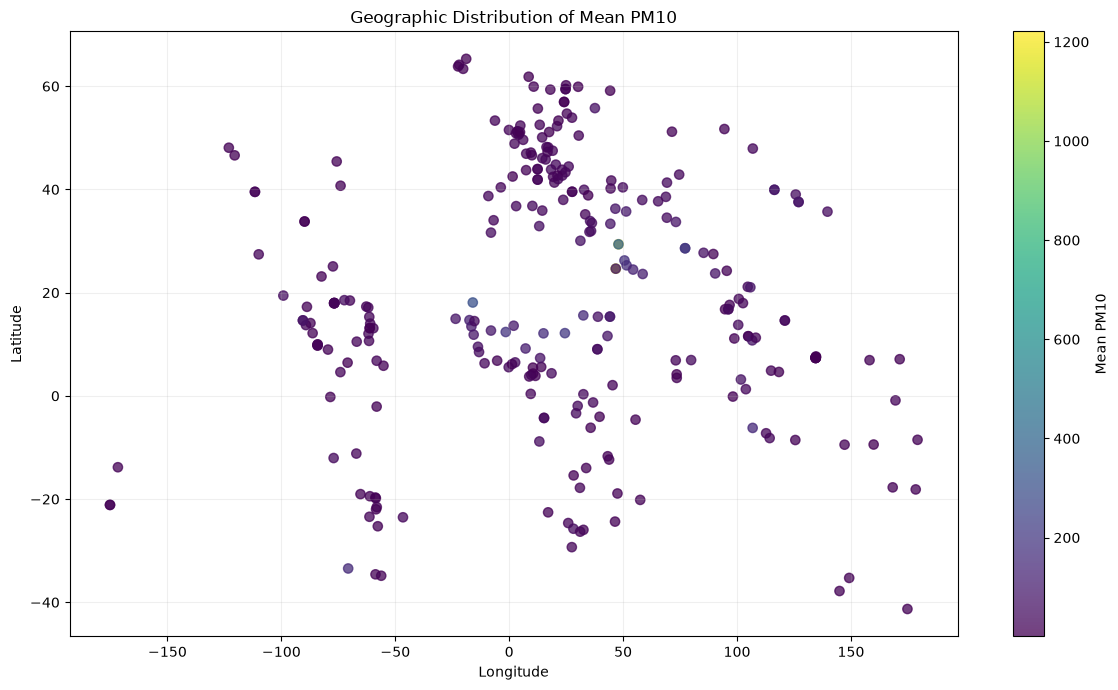

In [187]:
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    location_spatial["longitude"],
    location_spatial["latitude"],
    c=location_spatial["mean_PM10"],
    s=45,
    alpha=0.75
)

plt.colorbar(scatter, label="Mean PM10")

plt.title("Geographic Distribution of Mean PM10")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/geographic_mean_pm10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [188]:
riyadh = weather[
    (weather["country"] == "Saudi Arabia") &
    (weather["location_name"] == "Riyadh")
]

print("Riyadh observations:", len(riyadh))

print("\nRiyadh PM10 statistics:")
print(riyadh["air_quality_PM10"].describe())

print("\nHighest Riyadh PM10 observations:")
print(
    riyadh[
        [
            "last_updated",
            "temperature_celsius",
            "humidity",
            "wind_kph",
            "air_quality_PM2.5",
            "air_quality_PM10"
        ]
    ]
    .sort_values("air_quality_PM10", ascending=False)
    .head(10)
)

Riyadh observations: 865

Riyadh PM10 statistics:
count     865.000000
mean     1130.879826
std      1193.570668
min        30.500000
25%       184.900000
50%       739.075000
75%      1692.150000
max      6037.290000
Name: air_quality_PM10, dtype: float64

Highest Riyadh PM10 observations:
              last_updated  temperature_celsius  humidity  wind_kph  \
130220 2025-02-07 13:30:00                 18.2        24      20.5   
130219 2025-02-06 13:15:00                 27.4        17      28.1   
130166 2024-12-15 13:30:00                 14.1        13      21.2   
130308 2025-05-06 12:00:00                 31.4        11      23.4   
130149 2024-11-28 14:00:00                 18.1        37      15.8   
130172 2024-12-21 13:30:00                 20.6        21      25.2   
130161 2024-12-10 13:45:00                 21.4        25      20.5   
130188 2025-01-06 13:30:00                 19.1         9      28.4   
130316 2025-05-14 12:15:00                 37.1         6      22.3  

In [189]:
location_spatial.to_csv(
    "../outputs/tables/location_spatial_analysis.csv",
    index=False
)

pollution_hotspots.to_csv(
    "../outputs/tables/pollution_hotspots.csv",
    index=False
)

print("Spatial analysis tables saved successfully.")

Spatial analysis tables saved successfully.


In [190]:
feature_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Random_Forest_Importance": rf_model.feature_importances_,
    "Permutation_Importance_Mean": permutation_result.importances_mean,
    "Permutation_Importance_STD": permutation_result.importances_std
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "Random_Forest_Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance_df

,Feature,Random_Forest_Importance,Permutation_Importance_Mean,Permutation_Importance_STD
0,lag_1,0.565120,1.006550,0.093307
1,rolling_7,0.383145,0.350310,0.037645
2,lag_2,0.011200,-0.012550,0.017411
3,cos_day_of_year,0.011011,-0.026936,0.026543
4,rolling_14,0.010470,-0.037517,0.016358
5,lag_7,0.005006,0.021520,0.010643
6,lag_14,0.004422,-0.027093,0.015759
7,day_of_year,0.003109,-0.001018,0.004498
8,day_of_week,0.003095,-0.001090,0.021212
9,sin_day_of_year,0.003079,0.003907,0.007935


In [191]:
feature_importance_df.to_csv(
    "../outputs/tables/feature_importance_comparison.csv",
    index=False
)

print("Feature importance table saved.")

Feature importance table saved.


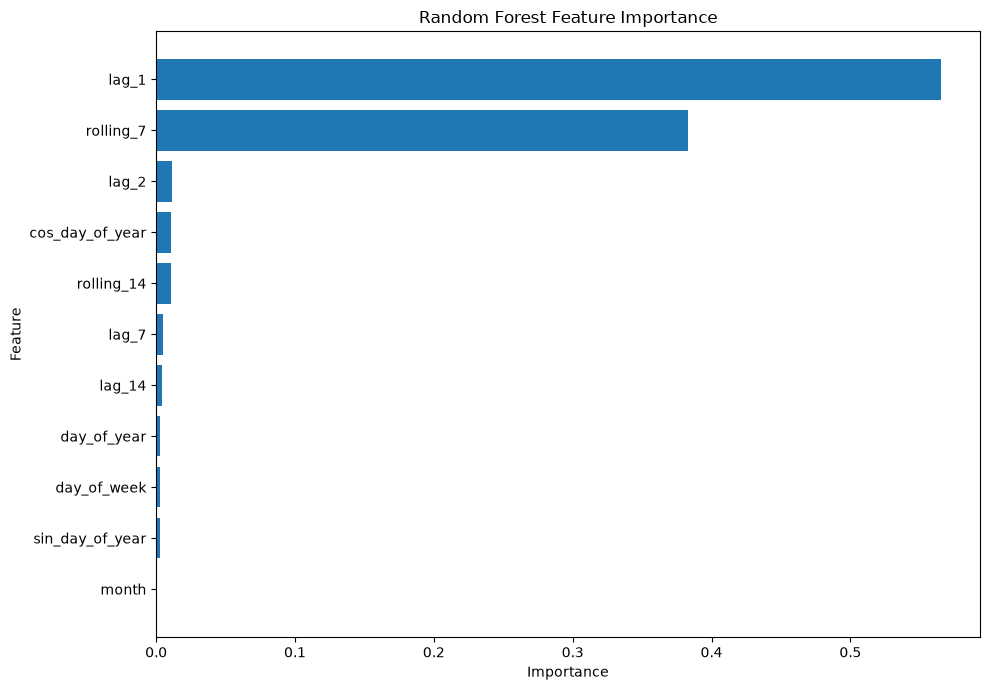

In [192]:
importance_plot = (
    feature_importance_df
    .sort_values("Random_Forest_Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    importance_plot["Feature"],
    importance_plot["Random_Forest_Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "../outputs/figures/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [193]:
import os

output_dirs = [
    "../outputs",
    "../outputs/figures",
    "../outputs/tables",
    "../outputs/models"
]

for directory in output_dirs:
    print(f"{directory}: {'Exists' if os.path.exists(directory) else 'Missing'}")

print("\nFigure files:")
for file in sorted(os.listdir("../outputs/figures")):
    print(" -", file)

print("\nTable files:")
for file in sorted(os.listdir("../outputs/tables")):
    print(" -", file)

../outputs: Exists
../outputs/figures: Exists
../outputs/tables: Exists
../outputs/models: Exists

Figure files:
 - co_by_humidity.png
 - coolest_countries.png
 - geographic_mean_pm10.png
 - geographic_mean_pm25.png
 - global_precipitation_spatial_distribution.png
 - global_temperature_spatial_distribution.png
 - kyiv_actual_vs_predicted.png
 - no2_by_humidity.png
 - ozone_by_humidity.png
 - pm10_by_humidity.png
 - pm2_5_by_humidity.png
 - random_forest_feature_importance.png
 - so2_by_humidity.png
 - temperature_by_latitude_band.png
 - temperature_vs_latitude.png
 - top_anomaly_countries.png
 - warmest_countries.png
 - weather_air_quality_correlation.png

Table files:
 - feature_importance_comparison.csv
 - forecasting_model_comparison.csv
 - location_spatial_analysis.csv
 - pollution_hotspots.csv


In [194]:
print("FINAL DATASET VALIDATION")
print("-" * 40)

print("Rows:", len(weather))
print("Columns:", len(weather.columns))
print("Duplicate rows:", weather.duplicated().sum())
print("Missing values:", weather.isna().sum().sum())

print(
    "Invalid humidity:",
    ((weather["humidity"] < 0) | (weather["humidity"] > 100)).sum()
)

print(
    "Invalid cloud:",
    ((weather["cloud"] < 0) | (weather["cloud"] > 100)).sum()
)

print(
    "Negative precipitation:",
    (weather["precip_mm"] < 0).sum()
)

print(
    "Negative wind:",
    (weather["wind_kph"] < 0).sum()
)

print(
    "Negative air-quality values:",
    (
        weather[
            [
                "air_quality_Carbon_Monoxide",
                "air_quality_Ozone",
                "air_quality_Nitrogen_dioxide",
                "air_quality_Sulphur_dioxide",
                "air_quality_PM2.5",
                "air_quality_PM10"
            ]
        ] < 0
    ).sum().sum()
)

FINAL DATASET VALIDATION
----------------------------------------
Rows: 168591
Columns: 49
Duplicate rows: 0
Missing values: 0
Invalid humidity: 0
Invalid cloud: 0
Negative precipitation: 0
Negative wind: 0
Negative air-quality values: 0


In [195]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.11.1 (tags/v3.11.1:a7a450f, Dec  6 2022, 19:58:39) [MSC v.1934 64 bit (AMD64)]

Python executable:
c:\Users\sharv\Downloads\Global-Weather-Forecasting\.venv\Scripts\python.exe


In [196]:
import os
import joblib
import json

# Create models directory if it does not already exist
os.makedirs("../outputs/models", exist_ok=True)

# Save trained models
joblib.dump(
    ridge_model,
    "../outputs/models/ridge_model.joblib"
)

joblib.dump(
    rf_model,
    "../outputs/models/random_forest_model.joblib"
)

joblib.dump(
    hgb_model,
    "../outputs/models/hist_gradient_boosting_model.joblib"
)

# Save ensemble weights
ensemble_weights_dict = {
    "Ridge": float(ensemble_weights[0]),
    "Random Forest": float(ensemble_weights[1]),
    "HistGradientBoosting": float(ensemble_weights[2])
}

with open(
    "../outputs/models/ensemble_weights.json",
    "w"
) as f:
    json.dump(ensemble_weights_dict, f, indent=4)

print("Models saved successfully!")
print()
print("Saved files:")

for file in os.listdir("../outputs/models"):
    print("-", file)

Models saved successfully!

Saved files:
- ensemble_weights.json
- hist_gradient_boosting_model.joblib
- random_forest_model.joblib
- ridge_model.joblib


In [197]:
# Save country-level climate summary
climate_country_summary = country_climate.copy()

climate_country_summary.to_csv(
    "../outputs/tables/climate_country_summary.csv",
    index=False
)

print("Saved climate_country_summary.csv")
print(climate_country_summary.shape)

Saved climate_country_summary.csv
(211, 6)


In [200]:
print(weather.columns.tolist())

['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination', 'date', 'year', 'month', 'day', 'day_of_year', 'day_of_week', 'week_of_year', 'season']


In [201]:
# Show variables related to anomaly detection
[name for name in globals() if "anomal" in name.lower()]

['anomaly_features',
 'anomaly_df',
 'top_anomalies',
 'anomaly_by_country',
 'anomaly_by_location',
 'country_anomaly_rate',
 'top_anomaly_countries',
 'anomaly_summary',
 'anomaly_means',
 'anomaly_comparison',
 'anomaly_country_summary']

In [202]:
print(anomaly_df.shape)
print(anomaly_df.columns.tolist())
print()
print(anomaly_df.head())

(168591, 15)
['country', 'location_name', 'last_updated', 'temperature_celsius', 'precip_mm', 'humidity', 'wind_kph', 'pressure_mb', 'visibility_km', 'uv_index', 'air_quality_PM2.5', 'air_quality_PM10', 'anomaly_score', 'anomaly', 'anomaly_label']

   country      location_name        last_updated  temperature_celsius  \
0  Belgium  'S Gravenjansdijk 2024-05-31 16:15:00                 16.0   
1  Belgium  'S Gravenjansdijk 2024-06-01 16:30:00                 16.0   
2  Belgium  'S Gravenjansdijk 2024-06-04 16:15:00                 18.0   
3  Belgium  'S Gravenjansdijk 2024-06-05 16:15:00                 15.0   
4  Belgium  'S Gravenjansdijk 2024-06-11 16:15:00                 15.2   

   precip_mm  humidity  wind_kph  pressure_mb  visibility_km  uv_index  \
0       0.29        82      28.1       1014.0           10.0       4.0   
1       0.01        88      15.1       1019.0           10.0       4.0   
2       0.06        77      25.9       1011.0           10.0       4.0   
3       0.

In [203]:
# Create a proper country-level anomaly summary

anomaly_country_summary = (
    anomaly_df.groupby("country")
    .agg(
        total_observations=("anomaly", "size"),
        anomaly_count=("anomaly", lambda x: (x == -1).sum())
    )
    .reset_index()
)

anomaly_country_summary["anomaly_rate_percent"] = (
    anomaly_country_summary["anomaly_count"]
    / anomaly_country_summary["total_observations"]
    * 100
)

anomaly_country_summary = anomaly_country_summary.sort_values(
    "anomaly_count",
    ascending=False
)

anomaly_country_summary.to_csv(
    "../outputs/tables/anomaly_country_summary.csv",
    index=False
)

print("Saved anomaly_country_summary.csv")
print(anomaly_country_summary.shape)
print()
print(anomaly_country_summary.head(10))

Saved anomaly_country_summary.csv
(211, 4)

          country  total_observations  anomaly_count  anomaly_rate_percent
157  Saudi Arabia                 865            430             49.710983
94         Kuwait                 865            245             28.323699
78          India                 864            146             16.898148
172         Sudan                1727            125              7.237985
35          Chile                 863             96             11.123986
34           Chad                 867             78              8.996540
147         Qatar                 864             65              7.523148
36          China                 864             63              7.291667
12        Bahrain                 866             59              6.812933
26   Burkina Faso                 866             51              5.889145


In [204]:
[name for name in globals() if "environment" in name.lower() or "humidity" in name.lower()]

['humidity_aq']

In [205]:
print(type(humidity_aq))
print(humidity_aq.shape)
print(humidity_aq.columns.tolist())
print()
print(humidity_aq)

<class 'pandas.DataFrame'>
(4, 7)
['PM2_5', 'PM10', 'Ozone', 'NO2', 'SO2', 'CO', 'observations']

                       PM2_5        PM10      Ozone        NO2        SO2  \
humidity_group                                                              
Low (<40%)         37.168658  119.056581  78.642671  18.110901  16.300610   
Moderate (40–60%)  26.356944   46.528616  68.624600  16.405942  13.187279   
High (60–80%)      19.840487   31.052839  55.109254  12.510165   8.123577   
Very High (>80%)   16.329479   23.221714  45.055882  11.995460   5.975443   

                           CO  observations  
humidity_group                               
Low (<40%)         504.611641         27098  
Moderate (40–60%)  451.564345         29777  
High (60–80%)      413.287551         54044  
Very High (>80%)   361.006403         57672  


In [206]:
# Save environmental impact summary

environmental_impact_summary = humidity_aq.reset_index()

environmental_impact_summary.to_csv(
    "../outputs/tables/environmental_impact_summary.csv",
    index=False
)

print("Saved environmental_impact_summary.csv")
print(environmental_impact_summary.shape)
print()
print(environmental_impact_summary)

Saved environmental_impact_summary.csv
(4, 8)

      humidity_group      PM2_5        PM10      Ozone        NO2        SO2  \
0         Low (<40%)  37.168658  119.056581  78.642671  18.110901  16.300610   
1  Moderate (40–60%)  26.356944   46.528616  68.624600  16.405942  13.187279   
2      High (60–80%)  19.840487   31.052839  55.109254  12.510165   8.123577   
3   Very High (>80%)  16.329479   23.221714  45.055882  11.995460   5.975443   

           CO  observations  
0  504.611641         27098  
1  451.564345         29777  
2  413.287551         54044  
3  361.006403         57672  
